# get bachground density rho_s based on Winters et al. 1995

In [ ]:
# May 12. Expand to whole domain, not just the Sulu Sea

# May 19. get the data fro the Sulu Sea and Celebes Sea seperately

# May 27. Recheck the z_star and remove a few useless cells.

# June 23. Tsorted_2

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import xmitgcm 
import os
from tqdm import tqdm
%matplotlib inline
import scipy
from scipy.signal import butter, filtfilt

# NOTES and python code for data processing:
# this is the main script to process the data, including:

In [3]:
# 0. intialize zarr dataset (00_init_zarr.py)
%run 00_init_zarr.py

Initializing /storage/ceoas-scratch/liux8/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens_Tsorted_2/zarr_output/u.zarr
Initializing /storage/ceoas-scratch/liux8/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens_Tsorted_2/zarr_output/v.zarr
Initializing /storage/ceoas-scratch/liux8/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens_Tsorted_2/zarr_output/phihyd.zarr
Initializing /storage/ceoas-scratch/liux8/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens_Tsorted_2/zarr_output/theta.zarr
Done.


In [ ]:
# 1. write the data (u, v, theta, phihyd) to the zarr dataset (01_write_mds_to_zarr.py) using slurm (sbatch run_01_write_mds_to_zarr.sh)
# 2. get baroclinic part of pressure and velocity
#   2.0 get the pressure (baroclinic) data (02_get_pressure_bc.py) using slurm (sbatch run_02_get_pressure.sh)
#   2.1 get velocity (baroclinic) data (02_1_get_velocity_bc.py) using slurm (sbatch run_02_1_get_velocity_bc.sh)
#   2.2 get rho data (022_get_rho.py) using slurm (sbatch run_022_get_rho.sh)

# got the the following cells to check the data

In [31]:
# 3. highpass u, v, and pressure (cutoff period = 16 hours) 
#   3.0 initialize high-passed velocity
%run 03_0_init_highpass_velocity_zarr.py
#   3.1 apply high-pass filter to the velocity data (03_1_highpass_velocity_zarr.py) by slurm (sbatch run_03_1_highpass_velocity_zarr.sh)
#   3.2 apply high-pass filter to the pressure data (03_2_highpass_pressure_zarr.py) by slurm (sbatch run_03_2_highpass_pressure_zarr.sh)

# 4. get energy fluxes (04_get_energy_flux.py) by slurm (sbatch run_04_get_energy_flux.sh)
# 5. get vertical integrated energy fluxes xdir (05_get_energy_vert_int_fx.py) and ydir (05_get_energy_vert_int_fy.py) 
#       by slurm (sbatch run_05_get_vert_int_energy_flux.sh)


Initialized /home/ceoas/liux8/work/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens_Tsorted_2/zarr_output/u_bc_highpass_pl66.zarr  shape=(600,87,1908,1520)  chunks=(20, 10, 128, 128)
Initialized /home/ceoas/liux8/work/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens_Tsorted_2/zarr_output/v_bc_highpass_pl66.zarr  shape=(600,87,1908,1520)  chunks=(20, 10, 128, 128)
Initialized /home/ceoas/liux8/work/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens_Tsorted_2/zarr_output/p_rho_bc_highpass_pl66.zarr  shape=(600,87,1908,1520)  chunks=(20, 10, 128, 128)
Done. You can now submit 03_1_run_highpass_velocity_zarr.sh safely.


<Figure size 640x480 with 0 Axes>

In [ ]:
# GET energy fluxex by KE and PE
# 6. get kinetic energy (06_get_ke_from_ubc_hp.py) by slurm (sbatch run_06_get_ke_from_ubc_hp.sh)
# 7. get APE 
#   7.0 ref rho (07_0_get_background_den_profile_87layers_v3.py) by slurm (sbatch 07_0_run_get_background_den_profile_87layers.sh)
#   7.1 get APE (07_1_get_local_zstar.py) by slurm (sbatch run_07_1_get_local_zstar.sh)
#   7.2 get APE fluxes (072_get_ape_flux_from_rho.py) by slurm (sbatch run_072_get_ape_flux_from_rho.sh)

In [ ]:
# to make the interval of the background density profile 1 tidal period 
# 8. get APE (1-tidal interval)
#   8.0 get background density profile (08_0_get_background_den_profile_1tidal.py) by slurm (sbatch run_08_0_get_background_den_profile_1tidal.sh)
#   8.1 get APE (08_1_get_local_zstar_1tidal.py) by slurm (sbatch run_08_1_get_local_zstar_1tidal.sh)
#   8.2 get APE fluxes (082_get_ape_flux_from_rho_1tidal.py) by slurm (sbatch run_082_get_ape_flux_from_rho_1tidal.sh)

# 1. prepare constants and functions

In [2]:
# parameters for EOS equation of state
rho0 = 1026.5
T0 = 0
alpha = 2e-4
g=9.81

CASE_DIR = '/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_ctrl_bot_intensify_Tsorted_2'
data_dir = '/home/ceoas/liux8/work/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens_Tsorted_2/zarr_output'

ds_grid = xmitgcm.open_mdsdataset(CASE_DIR, prefix = 'outs_sn', iters=[0] )

lon = ds_grid.XC
lat = ds_grid.YC

# 2. load data and pick up a zonal section for testing



In [226]:
theta = xr.open_zarr(os.path.join(data_dir, 'theta.zarr'), consolidated=False)

In [20]:
# coordinates and grid info for the section
# ds = xmitgcm.open_mdsdataset(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_ctrl_bot_intensify/', prefix=['outs_sn'], iters=[0])
ds = xmitgcm.open_mdsdataset(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_ctrl_bot_intensify_Tsorted_2/', prefix=['outs_sn'], iters=[0])

# lon_sec = ds.XC.isel(XC=slice(570,970)).values
# lat_sec = ds.YC.isel(YC=slice(1100, 1101)).values
z_centers = ds.Z.values
# z_faces = ds.Zl.values
drF = ds.drF.values
hFacS = ds.hFacS.values
hFacW = ds.hFacW.values
# drC = ds.drC.values
# rA = ds.rA.isel(YC=slice(1100, 1101), XC=slice(570,970)).values
# hFacC = ds.hFacC.isel(YC=slice(1100, 1101), XC=slice(570,970)).values

In [9]:
t00 = theta.theta.isel(time = 0, x=700, y=1100).values
t00[t00==0] = np.nan

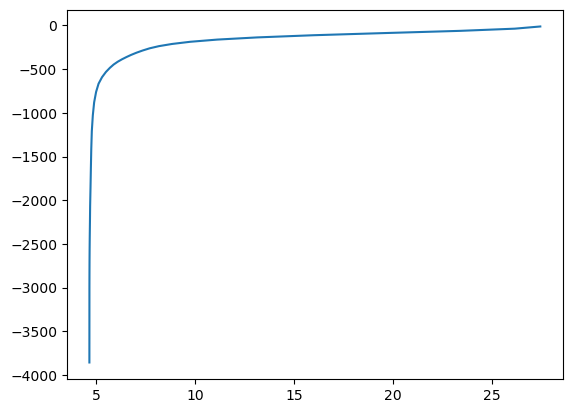

In [10]:
plt.plot(t00, z_centers)
# plt.xlim(4.66,4.67)

## 2.1 get velcity and check the spectrum of the velocity at one location

In [32]:
u = xr.open_zarr(os.path.join(data_dir, 'u.zarr'), consolidated=False)
v = xr.open_zarr(os.path.join(data_dir, 'v.zarr'), consolidated=False)
u_bc = xr.open_zarr(os.path.join(data_dir, 'u_bc.zarr'), consolidated=False)
u_bc_hp = xr.open_zarr(os.path.join(data_dir, 'u_bc_highpass.zarr'), consolidated=False)
u_bc_hp_pl66 = xr.open_zarr(os.path.join(data_dir, 'u_bc_highpass_pl66.zarr'), consolidated=False)
v_bc_hp = xr.open_zarr(os.path.join(data_dir, 'v_bc_highpass.zarr'), consolidated=False)
p_bc = xr.open_zarr(os.path.join(data_dir, 'p_rho_bc.zarr'), consolidated=False)
p_bc_hp = xr.open_zarr(os.path.join(data_dir, 'p_rho_bc_highpass.zarr'), consolidated=False)


In [34]:
u_sulu = u.u.isel(y =1100, x=700)
u_bc_sulu = u_bc.u_bc.isel(y =1100, x=700)
u_bc_hp_sulu = u_bc_hp.u_bc_highpass.isel(y =1100, x=700)
u_bc_hp_pl66_sulu = u_bc_hp_pl66.u_bc_highpass_pl66.isel(y =1100, x=700)
v_bc_hp_sulu = v_bc_hp.v_bc_highpass.isel(y =1100, x=700)
p_bc_sulu = p_bc.p_rho_bc.isel(y =1100, x=700)
p_bc_hp_sulu = p_bc_hp.p_rho_bc_highpass.isel(y =1100, x=700)

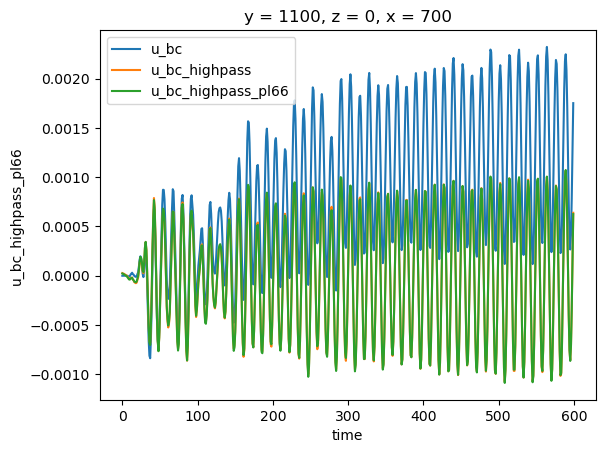

In [35]:
# u_sulu.isel(z=0).plot()
u_bc_sulu.isel(z = 0).plot(label = 'u_bc')
# (p_bc_sulu.isel(z = 10)).plot()
u_bc_hp_sulu.isel(z = 0).plot(label = 'u_bc_highpass')
u_bc_hp_pl66_sulu.isel(z = 0).plot(label = 'u_bc_highpass_pl66')
# u_bc_sulu.isel(z = 0).rolling( time=16).mean().plot()
filtered_data3 = u_bc_sulu.isel(z = 0)-u_bc_sulu.isel(z = 0).rolling(time=16).mean()
# plt.plot(filtered_data3)
# plt.xlim(0,50)
plt.legend()

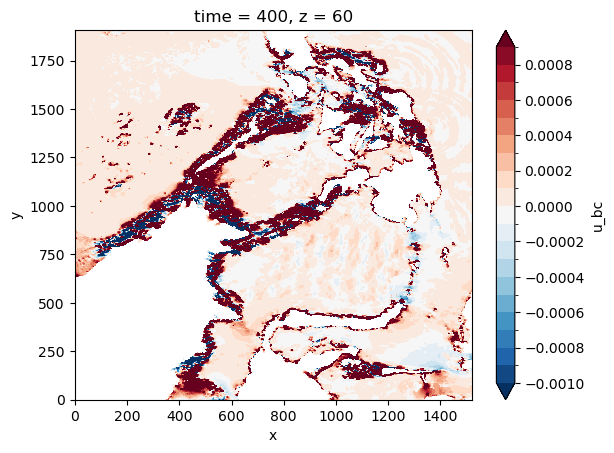

In [260]:
u_bc.isel(time=400,z=60).u_bc.plot.contourf(levels=np.arange(-0.001,0.001,0.0001))

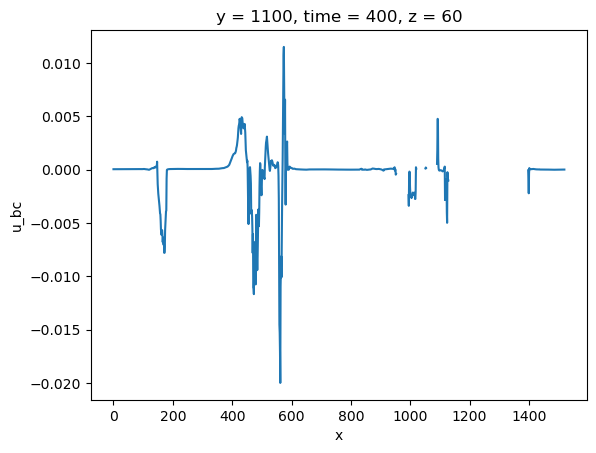

In [261]:
u_bc.isel(y=1100, z=60, time=400).u_bc.plot()

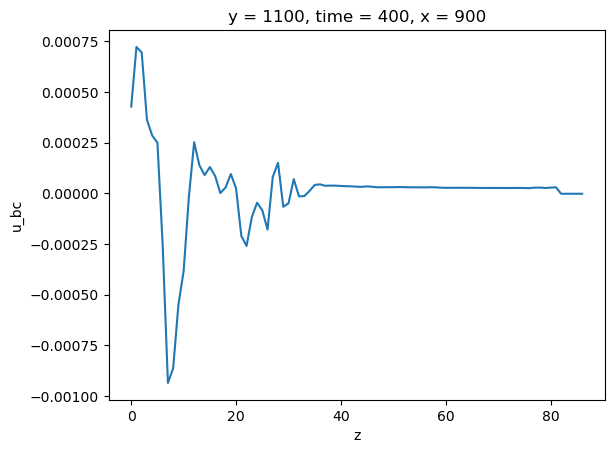

In [257]:
u_bc.isel(y=1100, x=900, time=400).u_bc.plot()

In [ ]:
def power_spectral_density_fft(var,fs=1/3600):

    # fs = 5.0
    N = len(var)
    var = scipy.signal.detrend(var, type='linear')
    fft = np.fft.fft(var)
    frequencies = np.fft.fftfreq(N, 1/fs)[:N//2]  # Positive frequencies only
    psd = (1/(fs * N)) * np.abs(fft[:N//2])**2  # PSD
    psd[1:-1] *= 2  # Double non-DC/nyquist components for one-sided spectrum

    return frequencies, psd

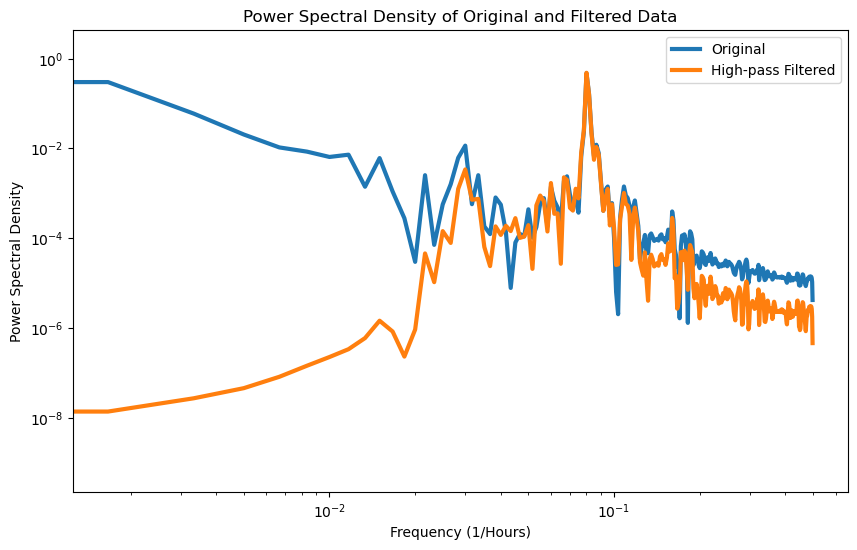

In [39]:
data_u_bc_p1 = u_bc_sulu.isel(z=0).values
data_u_hp_p1 = u_bc_hp_pl66_sulu.isel(z=0).values
freq, psd_orig = power_spectral_density_fft(data_u_bc_p1)
freq, psd_hp = power_spectral_density_fft(data_u_hp_p1)

plt.figure(figsize=(10,6))
plt.loglog(freq*3600, psd_orig, label='Original',linewidth=3)
plt.loglog(freq*3600, psd_hp, label='High-pass Filtered', linewidth=3)
# plt.plot(freq*3600, psd_orig, label='Original', linewidth=3)
# plt.plot(freq*3600, psd_hp, label='High-pass Filtered', linewidth=3)
# plt.vlines(10.5, 1e-8, 1e-1, color='k', linestyle='--', label='11-hour period')
# plt.vlines(14.5, 1e-8, 1e-1, color='k', linestyle='--', label='14.5-hour period')
# plt.vlines(1/16, 1e-8, 1e-1, color='k', linestyle='--', label='16-hour period')
# plt.vlines(36, 1e-8, 1e-1, color='k', linestyle='--', label='36-hour period')
# plt.xlim(1/500, 1/1.9)
# plt.ylim(0, 1e-1)
# plt.xlabel('Period (Hours)')
plt.xlabel('Frequency (1/Hours)')
plt.ylabel('Power Spectral Density')
plt.title('Power Spectral Density of Original and Filtered Data')
plt.legend()

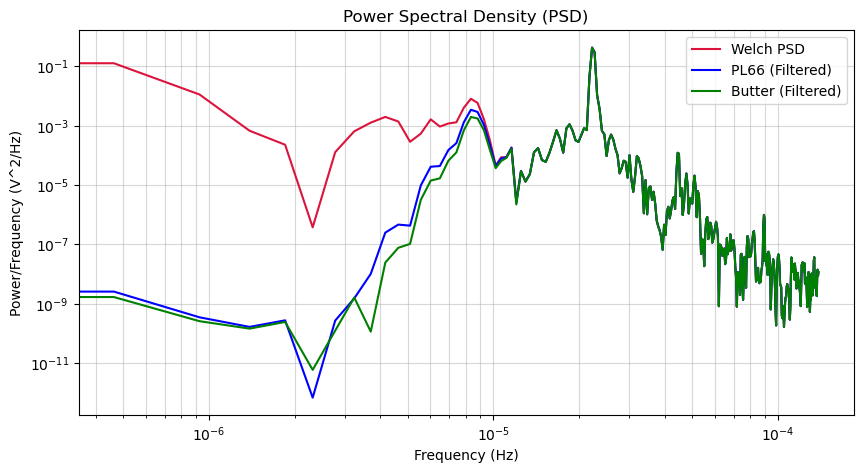

In [44]:
from scipy.signal import welch

# 1. Generate a noisy test signal
fs = 1/3600  # Sampling frequency (Hz)
t = np.arange(0, 600, 1/fs)  # 10 seconds of data
# signal = np.sin(2 * np.pi * 50 * t)  # 50 Hz sine wave
x = u_bc_sulu.isel(z=0).values
x2 = u_bc_hp_pl66_sulu.isel(z=0).values
x3 = u_bc_hp_sulu.isel(z=0).values
# noise = np.random.normal(0, 1.5, size=t.shape)  # White noise
# x = signal + noise

# 2. Compute the Power Spectral Density (PSD)
frequencies, psd = welch(x, fs=fs, nperseg=1024)
freq2, psd2 = welch(x2, fs=fs, nperseg=1024)
freq3, psd3 = welch(x3, fs=fs, nperseg=1024)

# 3. Plot the results
plt.figure(figsize=(10, 5))
plt.loglog(frequencies, psd, label='Welch PSD', color='crimson')
plt.loglog(freq2, psd2, label='PL66 (Filtered)', color='blue')
plt.loglog(freq3, psd3, label='Butter (Filtered)', color='green')
plt.title('Power Spectral Density (PSD)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power/Frequency (V^2/Hz)')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()

In [90]:
def highpass_filter(data, cutoff, fs, order=7):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    # Get the Butterworth filter coefficients
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    # Apply the filter
    y = filtfilt(b, a, data)
    return y

def lowpass_filter(data, cutoff, fs, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    # Get the Butterworth filter coefficients
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    # Apply the filter
    y = filtfilt(b, a, data)
    return y

# Example parameters
fs = 1.0       # Sample rate (Hz)
cutoff = 1/16.0     # Cutoff frequency (Hz)
data = u_bc_sulu.isel(z = 0).values

filtered_data = highpass_filter(data, cutoff, fs)
filtered_data2 = lowpass_filter(data, cutoff, fs)

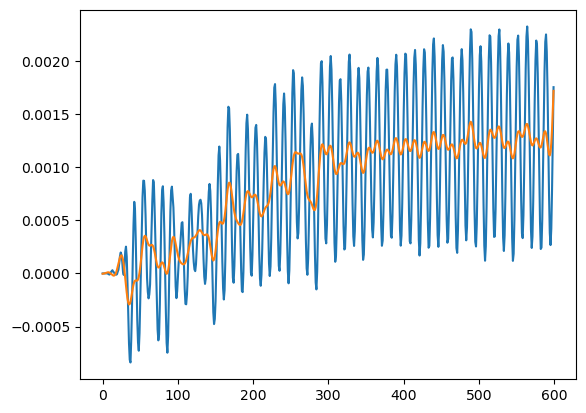

In [83]:
plt.plot(data)
plt.plot(filtered_data2)

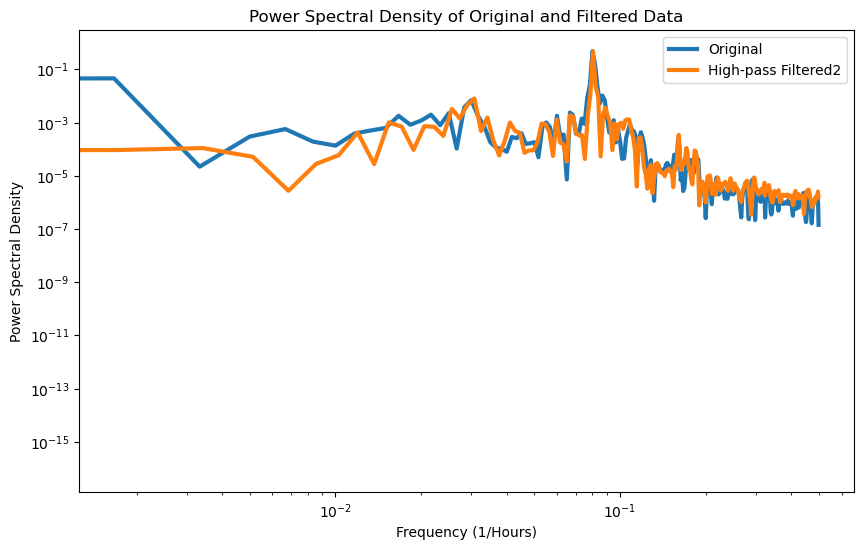

In [102]:
freq, psd_orig = power_spectral_density_fft(data)
freq, psd_hp = power_spectral_density_fft(filtered_data)
freq2, psd_hp2 = power_spectral_density_fft(filtered_data3[15:])

plt.figure(figsize=(10,6))
plt.loglog(freq*3600, psd_orig, label='Original',linewidth=3)
# plt.loglog(freq*3600, psd_hp, label='High-pass Filtered', linewidth=3)
plt.loglog(freq2*3600, psd_hp2, label='High-pass Filtered2', linewidth=3)
# plt.plot(1/freq/3600, psd_orig, label='Original',linewidth=3)
# plt.plot(1/freq/3600, psd_band, label='Bandpass Filtered', linewidth=3)
# plt.vlines(10.5, 1e-8, 1e-1, color='k', linestyle='--', label='11-hour period')
# plt.vlines(14.5, 1e-8, 1e-1, color='k', linestyle='--', label='14.5-hour period')
# plt.vlines(1/16, 1e-8, 1e-1, color='k', linestyle='--', label='16-hour period')
# plt.vlines(36, 1e-8, 1e-1, color='k', linestyle='--', label='36-hour period')
# plt.xlim(1/500, 1/1.9)
# plt.ylim(0, 1e-1)
# plt.xlabel('Period (Hours)')
plt.xlabel('Frequency (1/Hours)')
plt.ylabel('Power Spectral Density')
plt.title('Power Spectral Density of Original and Filtered Data')
plt.legend()

In [17]:
# verify FX and FY

fx3d = xr.open_zarr(os.path.join(data_dir, 'Fx.zarr'), consolidated=False)
fy3d = xr.open_zarr(os.path.join(data_dir, 'Fy.zarr'), consolidated=False)

fx = xr.open_zarr(os.path.join(data_dir, 'fx_ver_int_bp.zarr'), consolidated=False)
fy = xr.open_zarr(os.path.join(data_dir, 'fy_ver_int_bp.zarr'), consolidated=False)

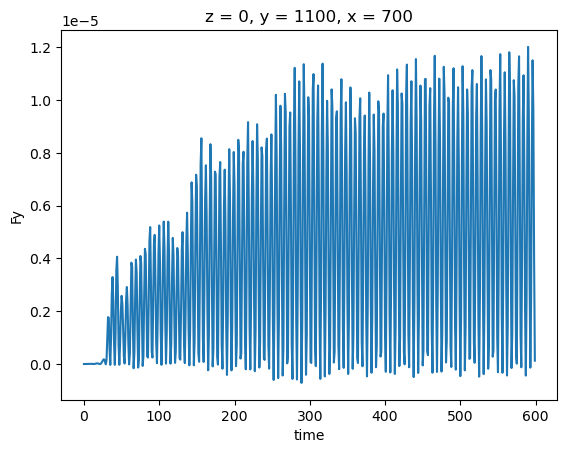

In [18]:
# fx3d.Fx.isel(x = 700, y = 1100, z= 0).plot()
fy3d.Fy.isel(x = 700, y = 1100, z= 0).plot()

Text(0.5, 1.0, 'Mean Baroclinic Energy Flux Vectors')

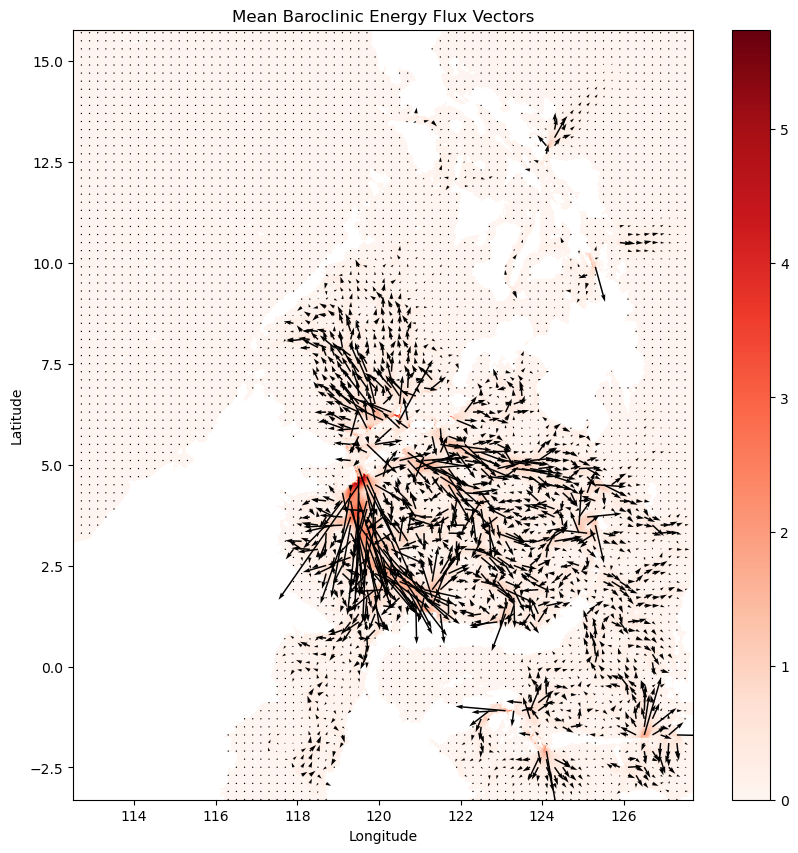

In [21]:
# fxy = np.sqrt(fx.fx_ver_int**2+fy.fy_ver_int**2)

# fxy.isel(time=slice(400,450)).mean(dim='time').plot(vmax=1e-6)
Fx_ver_int_tavg_vint = fx.fx_ver_int.isel(time=slice(400,450)).mean(dim='time')* np.sum(drF[:, np.newaxis, np.newaxis] * hFacW, axis=0)*rho0
Fy_ver_int_tavg_vint = fy.fy_ver_int.isel(time=slice(400,450)).mean(dim='time')* np.sum(drF[:, np.newaxis, np.newaxis] * hFacS, axis=0)*rho0

Fxy_ver_int_mean = np.sqrt(Fx_ver_int_tavg_vint**2 + Fy_ver_int_tavg_vint**2)

plt.figure(figsize=(10,10))
plt.pcolormesh(lon, lat, Fxy_ver_int_mean, cmap='Reds')
plt.colorbar()
plt.quiver(lon[0:-1:20], lat[0:-1:20], Fx_ver_int_tavg_vint[0:-1:20, 0:-1:20], Fy_ver_int_tavg_vint[0:-1:20, 0:-1:20])
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Mean Baroclinic Energy Flux Vectors')

## 2.2 plot the energy fluxes

### 2.2.1 compare pres and u - ctrl_bot_intens and ctrl_bot_intens_Tsorted

In [11]:

pres_0 = xr.open_zarr(os.path.join('/home/ceoas/liux8/work/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens/zarr_output', 'p_rho_bc.zarr'), consolidated=False)
pres_1 = xr.open_zarr(os.path.join('/home/ceoas/liux8/work/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens_Tsorted/zarr_output', 'p_rho_bc.zarr'), consolidated=False)
pres_0_bp = xr.open_zarr(os.path.join('/home/ceoas/liux8/work/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens/zarr_output', 'p_rho_bc_bp_semidiurnal.zarr'), consolidated=False)
pres_1_lp = xr.open_zarr(os.path.join('/home/ceoas/liux8/work/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens_Tsorted/zarr_output', 'p_rho_bc_lowpass.zarr'), consolidated=False)
pres_1_bp = xr.open_zarr(os.path.join('/home/ceoas/liux8/work/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens_Tsorted/zarr_output', 'p_rho_bc_bp_semidiurnal.zarr'), consolidated=False)

pres_0_sulu = pres_0.p_rho_bc.isel(z=0, y=1100, x=700)
pres_1_sulu = pres_1.p_rho_bc.isel(z=0, y=1100, x=700)
pres_0_sulu_bp = pres_0_bp.p_rho_bc_bp_semidiurnal.isel(z=0, y=1100, x=700)
pres_1_sulu_lp = pres_1_lp.p_rho_bc_lowpass.isel(z=0, y=1100, x=700)
pres_1_sulu_bp = pres_1_bp.p_rho_bc_bp_semidiurnal.isel(z=0, y=1100, x=700)

pres_1_sulu_dmean = pres_1_sulu-pres_1_sulu.mean(dim='time')
pres_1_sulu_lp_dmean = pres_1_sulu_lp-pres_1_sulu_lp.mean(dim='time')

Text(0.5, 1.0, 'Comparison of Pressure at Sulu Sea (z=0, y=1100, x=700)')

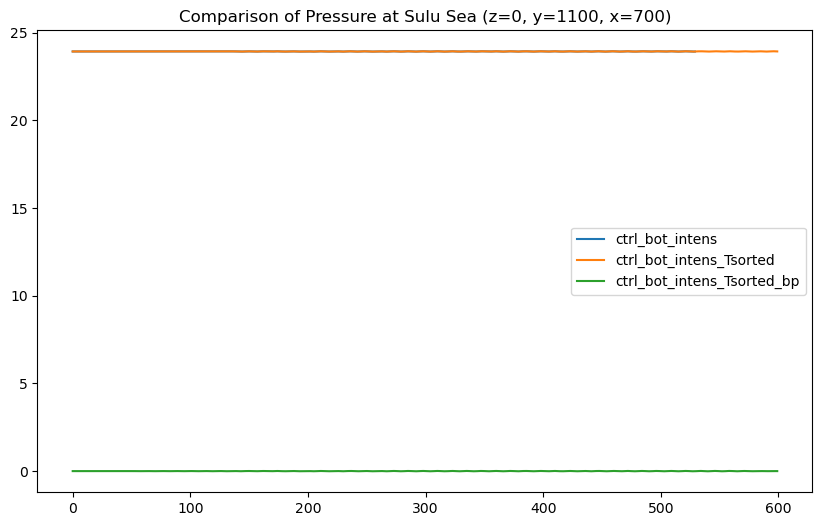

In [12]:
plt.figure(figsize=(10,6))
plt.plot(pres_0_sulu, label='ctrl_bot_intens')
plt.plot(pres_1_sulu, label='ctrl_bot_intens_Tsorted')
plt.legend()
plt.title('Comparison of Pressure at Sulu Sea (z=0, y=1100, x=700)')

(0.0, 550.0)

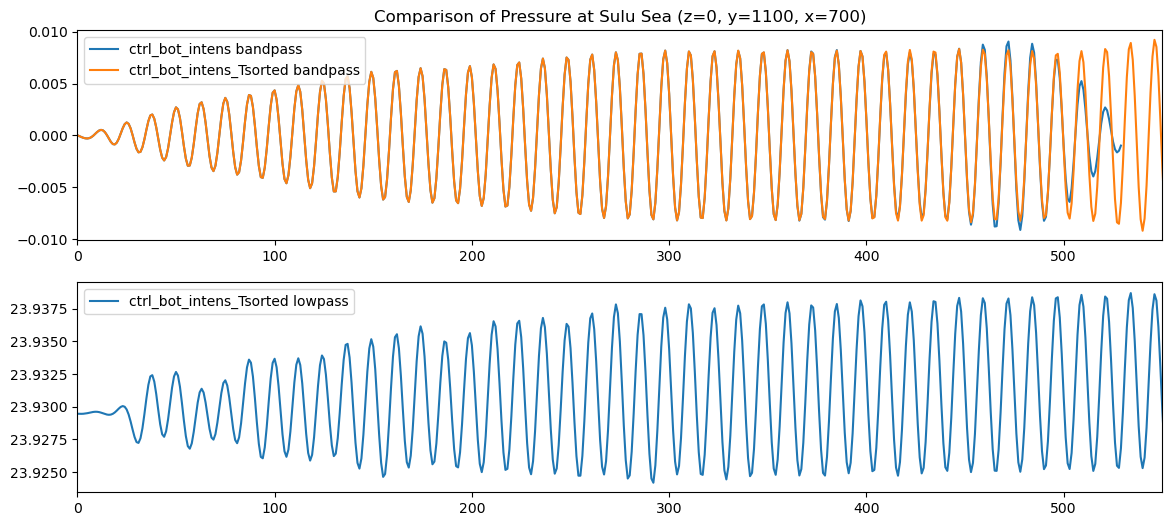

In [13]:
fig, ax = plt.subplots(2,1, figsize=(14,6))
ax[0].plot(pres_0_sulu_bp, label='ctrl_bot_intens bandpass')
ax[0].plot(pres_1_sulu_bp, label='ctrl_bot_intens_Tsorted bandpass')
ax[1].plot(pres_1_sulu_lp, label='ctrl_bot_intens_Tsorted lowpass')
ax[0].legend()
ax[1].legend()
ax[0].set_title('Comparison of Pressure at Sulu Sea (z=0, y=1100, x=700)')
ax[1].set_xlim(0, 550)
ax[0].set_xlim(0, 550)

### 2.2.2 compare velocity / 

In [30]:
u_0 = xr.open_zarr(os.path.join('/home/ceoas/liux8/work/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens/zarr_output', 'u_bc.zarr'), consolidated=False)
u_1 = xr.open_zarr(os.path.join('/home/ceoas/liux8/work/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens_Tsorted/zarr_output', 'u_bc.zarr'), consolidated=False)
u_0_bp = xr.open_zarr(os.path.join('/home/ceoas/liux8/work/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens/zarr_output', 'u_bc_bp_semidiurnal.zarr'), consolidated=False)
u_1_lp = xr.open_zarr(os.path.join('/home/ceoas/liux8/work/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens_Tsorted/zarr_output', 'u_bc_lowpass.zarr'), consolidated=False)
u_1_bp = xr.open_zarr(os.path.join('/home/ceoas/liux8/work/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens_Tsorted/zarr_output', 'u_bc_bp_semidiurnal.zarr'), consolidated=False)

u_0_sulu = u_0.u_bc.isel(z=0, y=1100, x=700)
u_1_sulu = u_1.u_bc.isel(z=0, y=1100, x=700)
u_0_sulu_bp = u_0_bp.u_bc_bp_semidiurnal.isel(z=0, y=1100, x=700)
u_1_sulu_lp = u_1_lp.u_bc_lowpass.isel(z=0, y=1100, x=700)
u_1_sulu_bp = u_1_bp.u_bc_bp_semidiurnal.isel(z=0, y=1100, x=700)

Text(0.5, 1.0, 'Comparison of Zonal Velocity at Sulu Sea (z=0, y=1100, x=700)')

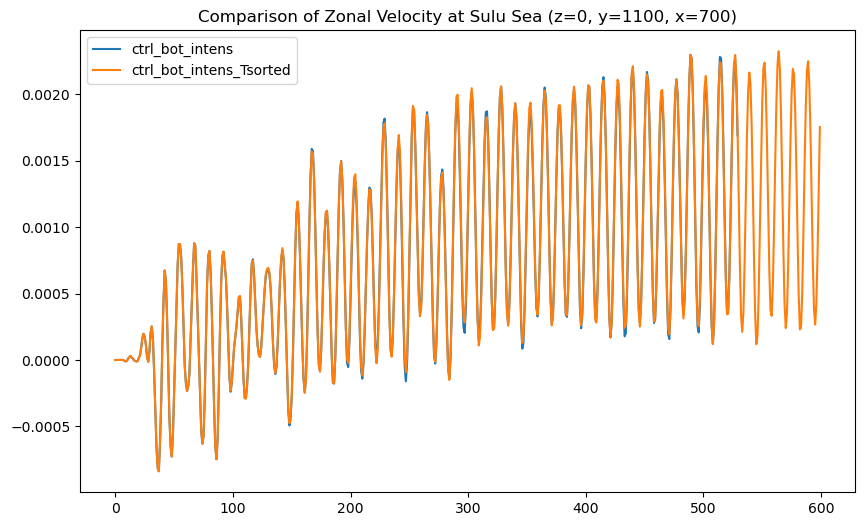

In [152]:
plt.figure(figsize=(10,6))
plt.plot(u_0_sulu, label='ctrl_bot_intens')
plt.plot(u_1_sulu, label='ctrl_bot_intens_Tsorted')
plt.legend()
plt.title('Comparison of Zonal Velocity at Sulu Sea (z=0, y=1100, x=700)')

Text(0.5, 1.0, 'Comparison of Zonal Velocity at Sulu Sea (z=0, y=1100, x=700)')

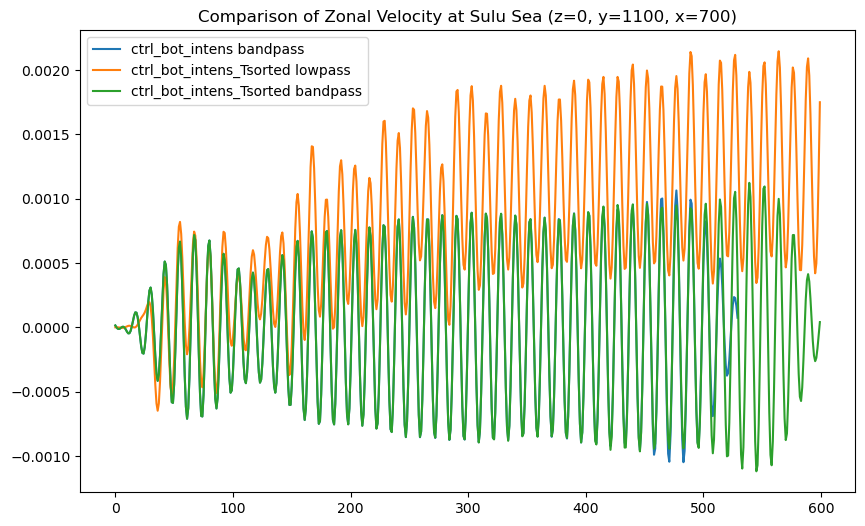

In [31]:
plt.figure(figsize=(10,6))
plt.plot(u_0_sulu_bp, label='ctrl_bot_intens bandpass')
plt.plot(u_1_sulu_lp, label='ctrl_bot_intens_Tsorted lowpass')
plt.plot(u_1_sulu_bp, label='ctrl_bot_intens_Tsorted bandpass')
plt.legend()
plt.title('Comparison of Zonal Velocity at Sulu Sea (z=0, y=1100, x=700)')

### 2.2.3 compare rho

In [51]:
ds_rho = xr.open_zarr(os.path.join(data_dir, 'rho.zarr'), consolidated=False)
ds_rho_lp = xr.open_zarr(os.path.join(data_dir, 'rho_lowpass.zarr'), consolidated=False)
rho_sulu = ds_rho.rho.isel(z = 10, y = 1100, x=700)
rho_lp_sulu = ds_rho_lp.rho_lowpass.isel(z = 10, y = 1100, x=700)

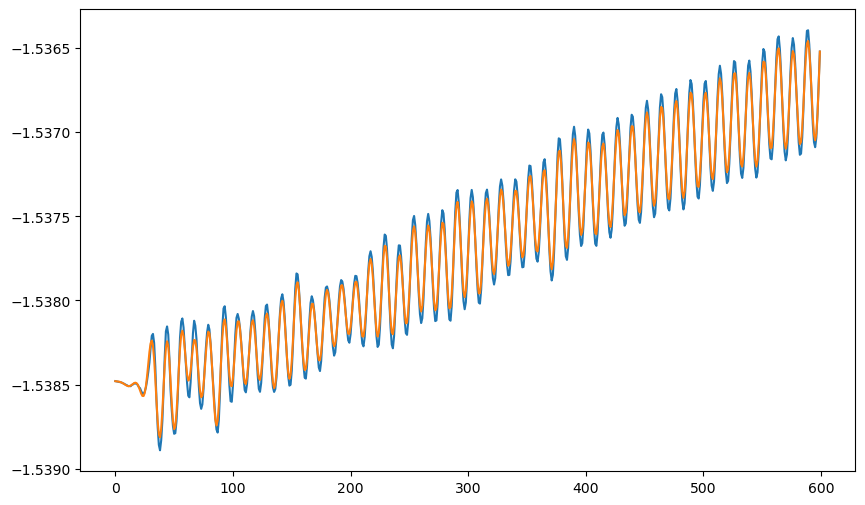

In [53]:
plt.figure(figsize=(10,6))
plt.plot(rho_sulu, label='rho')
plt.plot(rho_lp_sulu, label='rho lowpass')

In [4]:
ke = xr.open_zarr(os.path.join(data_dir, 'ke_bc_highpass.zarr'), consolidated=False)

ke_ver_int = np.sum(ke.ke_bc_highpass.isel(time=slice(400,450)).mean(dim='time')* drF[:, np.newaxis, np.newaxis] * hFacW, axis=0)*rho0 

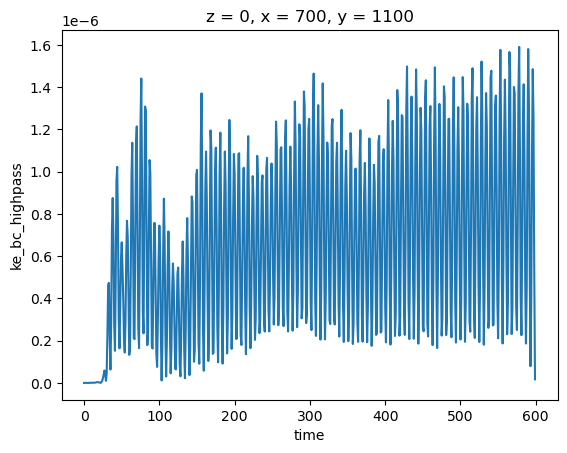

In [7]:
ke.isel(x=700, y=1100, z=0).ke_bc_highpass.plot()

In [14]:
Fx_ver_int = xr. open_zarr(os.path.join(data_dir, 'fx_ver_int_bp.zarr'), consolidated=False)
Fy_ver_int = xr. open_zarr(os.path.join(data_dir, 'fy_ver_int_bp.zarr'), consolidated=False)
# Fx_ver_int_bp = xr. open_zarr(os.path.join(data_dir, 'fx_ver_int_bp.zarr'), consolidated=False)
# Fy_ver_int_bp = xr. open_zarr(os.path.join(data_dir, 'fy_ver_int_bp.zarr'), consolidated=False)


In [7]:
def build_bandpass_filter() -> tuple[np.ndarray, np.ndarray]:
    fs = 1 / 3600
    cutoff1 = 1 / (14.5 * 3600)
    cutoff2 = 1 / (11 * 3600)
    # cutoff = 1 / (10.5 * 3600)
    # wn = [cutoff / (0.5 * fs)]
    wn = [cutoff1 / (0.5 * fs), cutoff2 / (0.5 * fs)]
    return butter(4, wn, btype="band")
b, a = build_bandpass_filter()
Fx_ver_int_lp = filtfilt(b, a, Fx_ver_int.fx_ver_int, axis=0).astype(np.float32, copy=False)

Fy_ver_int_lp = filtfilt(b, a, Fy_ver_int.fy_ver_int, axis=0).astype(np.float32, copy=False)


Text(0.5, 1.0, 'Comparison of Fx Vertical Integral at Sulu Sea (y=1100, x=700)')

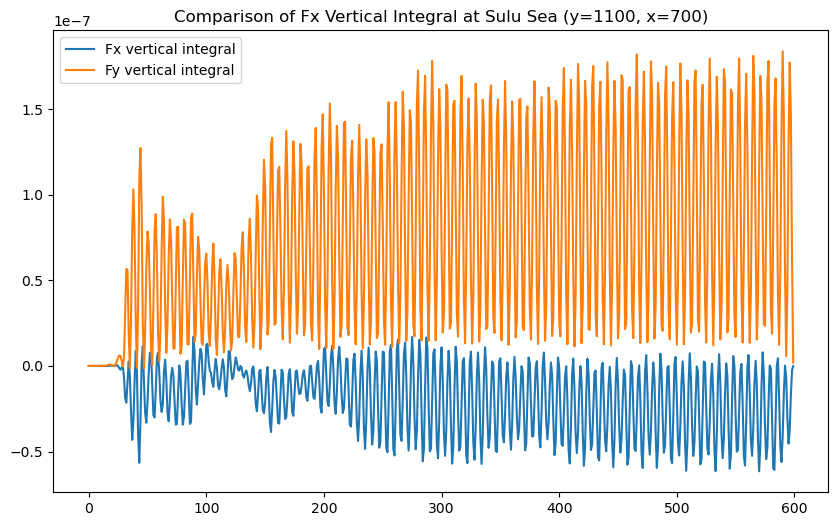

In [15]:
plt.figure(figsize=(10,6))
plt.plot(Fx_ver_int.fx_ver_int.isel(y=1100, x=700), label='Fx vertical integral')
plt.plot(Fy_ver_int.fy_ver_int.isel(y=1100, x=700), label='Fy vertical integral')
# plt.plot(Fy_ver_int_lp[:,1100,700], label='Fy vertical integral lowpass')
# plt.plot(Fx_ver_int_bp.fx_ver_int.isel(y=1100, x=700), label='Fx vertical integral bandpass')
plt.legend()
plt.title('Comparison of Fx Vertical Integral at Sulu Sea (y=1100, x=700)')

Text(0.5, 1.0, 'Comparison of Fy Vertical Integral at Sulu Sea (y=1100, x=700)')

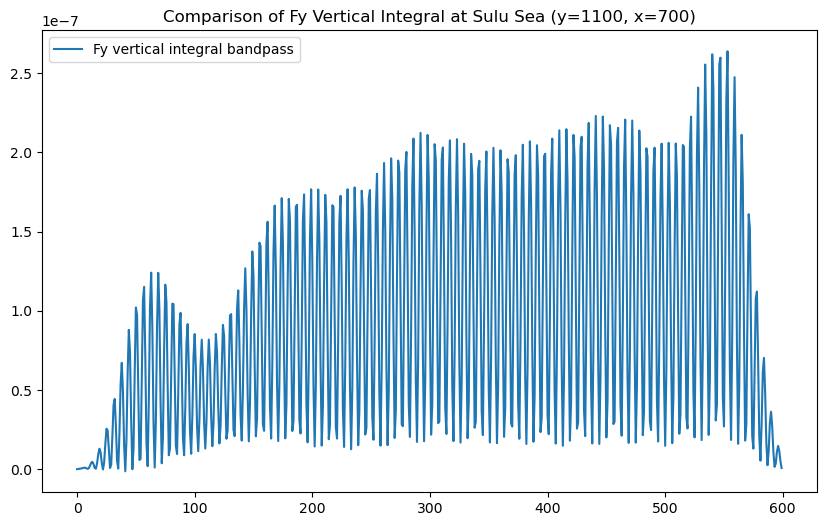

In [41]:
plt.figure(figsize=(10,6))
# plt.plot(Fy_ver_int.fy_ver_int.isel(y=1100, x=700), label='Fy vertical integral')
# plt.plot(Fy_ver_int_lp[:,1100,700], label='Fy vertical integral lowpass')
plt.plot(Fy_ver_int_bp.fy_ver_int.isel(y=1100, x=700), label='Fy vertical integral bandpass')
plt.legend()
plt.title('Comparison of Fy Vertical Integral at Sulu Sea (y=1100, x=700)')

In [16]:
Fy_ver_int_tavg = Fy_ver_int.fy_ver_int.isel(time = slice(450,500)).mean(dim='time')
Fx_ver_int_tavg = Fx_ver_int.fx_ver_int.isel(time = slice(450,500)).mean(dim='time')
# Fy_ver_int_tavg = Fy_ver_int_bp.fy_ver_int.isel(time=slice(450, 500)).mean(dim='time')
# Fx_ver_int_tavg = Fx_ver_int_bp.fx_ver_int.isel(time=slice(450, 550)).mean(dim='time')

drF = ds_grid.drF.values
hFacC = ds_grid.hFacC.values
hFacW = ds_grid.hFacW.values
hFacS = ds_grid.hFacS.values

Fx_ver_int_tavg_vint = Fx_ver_int_tavg * np.sum(drF[:, np.newaxis, np.newaxis] * hFacW, axis=0)*rho0
Fy_ver_int_tavg_vint = Fy_ver_int_tavg * np.sum(drF[:, np.newaxis, np.newaxis] * hFacS, axis=0)*rho0

Text(0.5, 1.0, 'Mean Baroclinic Energy Flux Vectors')

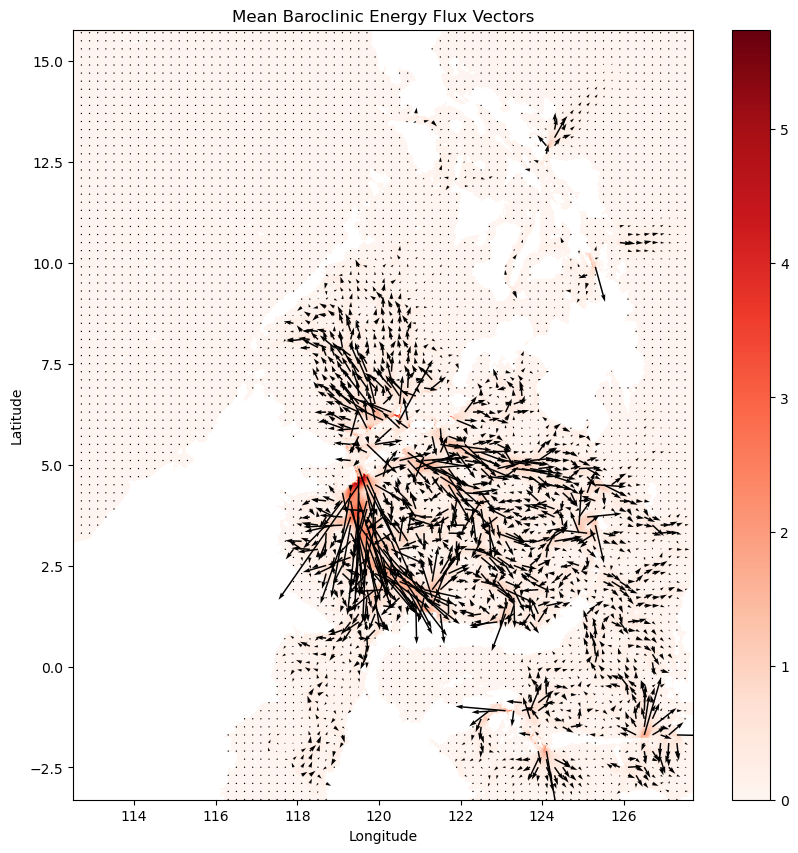

In [200]:
Fxy_ver_int_mean = np.sqrt(Fx_ver_int_tavg_vint**2 + Fy_ver_int_tavg_vint**2)

plt.figure(figsize=(10,10))
plt.pcolormesh(lon, lat, Fxy_ver_int_mean, cmap='Reds')
plt.colorbar()
plt.quiver(lon[0:-1:20], lat[0:-1:20], Fx_ver_int_tavg_vint[0:-1:20, 0:-1:20], Fy_ver_int_tavg_vint[0:-1:20, 0:-1:20])
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Mean Baroclinic Energy Flux Vectors')

## 2.3 get mean APE in the Sulu Sea

In [8]:
ds_rhoref0 = xr.open_dataset('rhoref_zstar_linear_case_ctrl_v3/rhoref_t_018.nc')
ds_rhoref1 = xr.open_dataset('rhoref_zstar_linear_case_ctrl_v3/rhoref_t_129.nc')

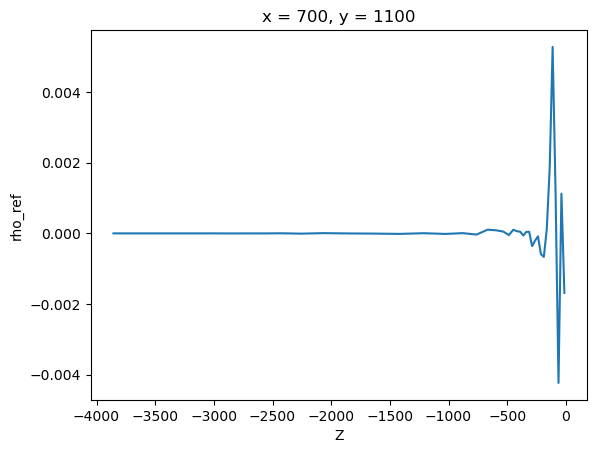

In [11]:

(ds_rhoref0.rho_ref.sel(x=700, y=1100)-ds_rhoref1.rho_ref.sel(x=700, y=1100)).plot()
# ds_rhoref1.rho_ref.sel(x=700, y=1100).plot()

In [28]:
zstar = xr.open_dataset('rhoref_zstar_linear_case_ctrl_v3/zstar_t_018.nc')
rho = xr.open_zarr(os.path.join(data_dir, 'rho.zarr'), consolidated=False)
theta = xr.open_zarr(os.path.join(data_dir, 'theta.zarr'), consolidated=False)

In [76]:
zarr_file = '/storage/ceoas-scratch/liux8/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens/zarr_output'

rho = xr.open_zarr(os.path.join(zarr_file, 'rho.zarr'), consolidated=False)
rho_mean = rho.isel(time=slice(240, 280)).mean(dim=['time'])

rho_mean_sulu = rho_mean.isel(y=1100, x=slice(570, 970))
# save rho_mean to zarr
rho_mean_sulu.to_netcdf('rho_mean_sulu_sec.nc', mode='w')


In [77]:

# i_min = 836
# i_max = 1579
# j_min = 508
# j_max = 1077
CASE_DIR = f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_ctrl_bot_intensify/'

print(f"Processing mean rho fields...")

# rho_t = xr.DataArray(rho_mean_sulu.rho.values, dims=("Z", "XC"))
rho_t = xr.open_dataset('rho_mean_sulu_sec.nc').rho.values
# drF = ds_mask["drF"] # center

# spatial_dims = rho_t.dims
# k_dim = spatial_dims[0]

_, ref = compute_background_PE(rho_t, rA, hFacC, vol, mask, V_ref_k, z_centers, )   # or rho from equation of state

zstar_all = np.full(rho_t.shape, np.nan, dtype=float)
zstar_all.ravel()[mask] = ref["zstar"]

theta_ref_ds = xr.Dataset(
    data_vars={
        "z_star": (("Z", "x"), zstar_all),
        "rho_ref": (("Z",), ref["rho_ref"]),
    },
    coords={"Z": z_centers,
            "x": lon_sec, 
            "y": lat_sec,}
)

# theta_ref_ds.to_netcdf(case_folder / f"rhoref_zstar_t_{it:03d}.nc", mode="w")
theta_ref_ds.to_netcdf("rhoref_zstar_mean.nc", mode="w")

# del ds_sn

Processing mean rho fields...


/tmp/ipykernel_2710620/1151127187.py:147: RuntimeWarning: invalid value encountered in scalar divide
  rho_ref[K-1-kk] = sum_rhoV / V_target  # assign back in top->bottom order


# 3. get APE based on Kang and Fringer (2011)

In [23]:
rhoref_tidal = xr.open_dataset('rhoref_zstar_linear_case_ctrl_v4_1tidal/zstar_t_499.nc')

In [25]:
rhoref_tidal.z_star.isel(x=700, y=1100).values

array([  -12.5     ,   -37.397602,   -62.391987,   -87.39014 ,
        -112.39129 ,  -137.41394 ,  -162.4444  ,  -187.47018 ,
        -212.48885 ,  -237.50581 ,  -262.52588 ,  -287.54364 ,
        -312.56326 ,  -337.58487 ,  -362.6045  ,  -388.27188 ,
        -416.049   ,  -447.77164 ,  -485.7535  ,  -532.9213  ,
        -592.29767 ,  -667.05304 ,  -761.11255 ,  -879.561   ,
       -1028.6583  , -1209.9272  , -1415.8466  , -1635.293   ,
       -1856.1881  , -2065.1084  , -2253.1545  , -2419.8755  ,
       -2567.6836  , -2698.725   , -2814.9082  , -2917.92    ,
       -3010.1458  , -3094.0818  , -3172.08    , -3245.651   ,
       -3316.539   , -3385.2305  , -3451.7314  , -3515.7156  ,
       -3577.4675  , -3637.1738  , -3694.75    , -3750.3213  ,
       -3803.9578  , -3855.596   , -3855.7266  , -3855.7266  ,
       -3855.7266  , -3855.7266  , -3855.7266  , -3855.7266  ,
       -3855.7266  , -3855.7266  , -3855.7266  , -3855.7266  ,
       -3855.7266  , -3855.7266  , -3855.7266  , -3855.

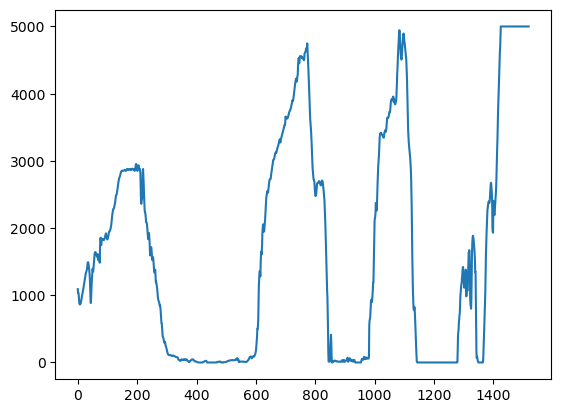

In [32]:
plt.plot(ds.Depth.isel(YC=1000))

In [4]:
## get vertical integrated APE2
ds_ape2_v3 = xr.open_zarr('zarr_output/APE2.zarr', consolidated=False)
ds_ape2_v4 = xr.open_zarr('zarr_output/APE2_1tidal.zarr', consolidated=False)
ds_ape2_integ = xr.open_zarr('zarr_output/APE2_1tidal_integ.zarr', consolidated=False)
ke = xr.open_zarr('zarr_output/ke_bc_highpass.zarr', consolidated=False)

# i_min = 836
# i_max = 1579
# j_min = 508
# j_max = 1077
# coordinates and grid info for the section
ds = xmitgcm.open_mdsdataset(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_ctrl_bot_intensify_Tsorted_2/', prefix=['outs_sn'], iters=[0])

# lon_sec = ds.XC.isel(XC=slice(j_min, j_max+1)).values
# lat_sec = ds.YC.isel(YC=slice(i_min, i_max+1)).values
lon_sec = ds.XC.values
lat_sec = ds.YC.values

drF = ds.drF.values
# hFacC = ds.hFacC.isel(YC=slice(i_min, i_max+1), XC=slice(j_min, j_max+1)).values
hFacC = ds.hFacC.values
z_centers = ds.Z.values

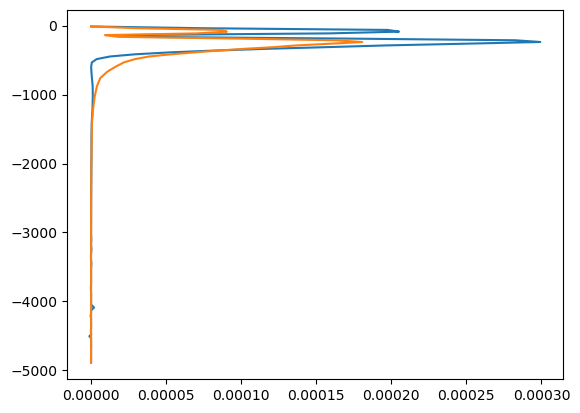

In [67]:

# plt.plot(ds_ape2_v3.APE2.isel(time=450, Z=slice(0, None), y=1100, x=900).values,z_centers[0:],  label='APE2')
plt.plot(ds_ape2_v4.APE2.isel(time=450, Z=slice(0, None), y=1100, x=900).values,z_centers[0:],  label='APE2')
plt.plot(ds_ape2_integ.APE2.isel(time=400, Z=slice(0, None), y=1100, x=900).values,z_centers[0:],  label='APE2')
# plt.ylim(-5000, 0)
# plt.title("APE2")
# plt.vlines(0, -5000, 0,'k', linestyles='--')
# plt.xlabel("APE2 (J/m^3)")
# plt.ylabel("Z (m)")

In [61]:
data_dir_ctrl = '/home/ceoas/liux8/work/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens_Tsorted_2/zarr_output'

rho_ref1 = xr.open_dataset(data_dir_ctrl + '/../rhoref_zstar_linear_case_ctrl_v4_1tidal/rhoref_t_396.nc')
rho_ref2 = xr.open_dataset(data_dir_ctrl + '/../rhoref_zstar_linear_case_ctrl_v4_1tidal/rhoref_t_409.nc')
zstar = xr.open_dataset(data_dir_ctrl + '/../rhoref_zstar_linear_case_ctrl_v4_1tidal/zstar_t_401.nc')
t1, t2, t_target = 396, 409, 401
w = (t_target - t1) / (t2 - t1)

rho_ref = rho_ref1.copy()
rho_ref["rho_ref"] = (1 - w) * rho_ref1["rho_ref"] + w * rho_ref2["rho_ref"]
rho_ref = rho_ref.assign_coords(time=t_target)
rho_ref = rho_ref.assign_coords(
    rho_ref_time_lower=t1,
    rho_ref_time_upper=t2,
    rho_ref_interp_weight=w,
)
rho = xr.open_zarr(os.path.join(data_dir_ctrl, 'rho.zarr'), consolidated=False)

rho_409 = rho.rho.isel(time=401)


In [62]:
# rho_r_p1 = rho_ref.rho_ref.isel(y = 1100, x = 900).values
# rho_p1 = rho_409.isel(y = 1100, x = 900).values

rho_r_p1 = rho_ref.rho_ref.isel(y = 100, x = 417).values
rho_p1 = rho_409.isel(y = 100, x = 417).values

In [63]:
# code for py file
g = 9.81
rho = np.asarray(rho_p1, dtype=np.float64)
z = np.asarray(z_centers, dtype=np.float64)
# z_ref = np.asarray(zstar.isel(y=1100, x=900).z_star.values, dtype=np.float64)
z_ref = np.asarray(zstar.isel(y=100, x=417).z_star.values, dtype=np.float64)
rho_ref = np.asarray(rho_r_p1, dtype=np.float64)

drf = np.asarray(drF, dtype=np.float64)
valid_ref = np.isfinite(z) & np.isfinite(rho_ref)

z_valid = z[valid_ref]
rho_valid = rho[valid_ref]
z_ref_valid = z_ref[valid_ref]
rho_ref_valid = rho_ref[valid_ref]
drf_valid = -drf[valid_ref]

order = np.argsort(z_valid)
z_sorted = z_valid[order]
rho_ref_sorted = rho_ref_valid[order]

# z_unique, inverse = np.unique(z_sorted, return_inverse=True)
# if z_unique.size < 2:
#     return np.full_like(rho, np.nan, dtype=np.float32)

# rho_ref_unique = np.zeros_like(z_unique, dtype=np.float64)
# counts = np.zeros_like(z_unique, dtype=np.int64)
# np.add.at(rho_ref_unique, inverse, rho_ref_sorted)
# np.add.at(counts, inverse, 1)
# rho_ref_unique /= counts

# Keep a face-integral array for diagnostics and consistency with notebook logic.
# z_faces = zf[0 : len(rho_ref_valid) + 1]
# F_faces = np.zeros(z_faces.size, dtype=np.float64)
# F_faces[1:] = np.cumsum(rho_ref_valid * drf_valid)

# Piecewise-linear integral using all intermediate z-centers between bounds.
def integrate_rho_between(z0: float, z1: float, z_grid: np.ndarray, rho_grid: np.ndarray) -> float:
    z_low = min(z0, z1)
    z_high = max(z0, z1)
    z_mid = z_grid[(z_grid > z_low) & (z_grid < z_high)]
    z_points = np.concatenate(([z0], z_mid, [z1]))
    rho_points = np.interp(z_points, z_grid, rho_grid)
    return float(np.trapz(rho_points, x=z_points))

# # F(z) = int(rho_ref dz) from z_unique[0] to z.
# def F_func(z_query: np.ndarray | float) -> np.ndarray | float:
#     z_query_arr = np.atleast_1d(np.asarray(z_query, dtype=np.float64))
#     out = np.empty_like(z_query_arr, dtype=np.float64)
#     z0 = float(z_unique[0])
#     for idx, zq in enumerate(z_query_arr):
#         out[idx] = integrate_rho_between(z0, float(zq), z_unique, rho_ref_unique)
#     if np.ndim(z_query) == 0:
#         return float(out[0])
#     return out

# ape2_t2 = np.zeros_like(rho, dtype=np.float64)
# for icou, zq, zrq in zip(range(len(z)), z, z_ref):
#     if not (np.isfinite(zrq) and np.isfinite(zq)):
#         continue
#     if zq < z_sorted[0] or zq > z_sorted[-1]:
#         ape2 =  np.full_like(rho, np.nan, dtype=np.float32)
#     if zrq < z_sorted[0] or zrq > z_sorted[-1]:
#         ape2 = np.full_like(rho, np.nan, dtype=np.float32)
#     ape2_t2[icou] = integrate_rho_between(zrq, zq, z_sorted, rho_ref_sorted)
# # ape2 = g * (rho * (z - z_ref) - (F_func(z) - F_func(z_ref)))
# ape2 = g * (rho * (z - z_ref) - ape2_t2)
# ape2[~(np.isfinite(z) & np.isfinite(rho_ref))] = np.nan
# # return ape2.astype(np.float32)

ape2_t2 = np.zeros_like(rho, dtype=np.float64)
# if j==100:
# print(f"p, zq, zrq for it={it}, j={j}, i={i}: z={z}, z_ref={z_ref}", flush=True)
for icou, zq, zrq in zip(range(len(z_valid)), z_valid, z_ref_valid):
    # if j==100:
    # print(f"Computing integral for it={it}, j={j}, i={i}, icou={icou}: zq={zq}, zrq={zrq}, z_sorted: {z_sorted}", flush=True)
    if not (np.isfinite(zrq) and np.isfinite(zq)):
        continue
    if zq < z_sorted[0] or zq > z_sorted[-1]:
        ape2_t2[icou] = np.nan
        continue
    if zrq < z_sorted[0] or zrq > z_sorted[-1]:
        ape2_t2[icou] = np.nan
        continue
    ape2_t2[icou] = integrate_rho_between(zrq, zq, z_sorted, rho_ref_sorted)
    # if j==100:
    # print(f"  Integral result for it={it}, j={j}, i={i}, icou={icou}: {ape2_t2[icou]}", flush=True)
# ape2 = g * (rho * (z - z_ref) - (F_func(z) - F_func(z_ref)))
ape2 = g * (rho * (z - z_ref) - ape2_t2)
# print(f'{ape2.shape}, {ape2_t2.shape}', flush=True)
# if j==100:
# print(f"APE2 debug at it={it}, j={j}, i={i}: ape2_t2={ape2_t2}, ape2={ape2}", flush=True)
# ape2[~(np.isfinite(z) & np.isfinite(rho_ref))] = np.nan
ape2[~(np.isfinite(z) & np.isfinite(rho_ref))] = np.nan
# return ape2.astype(np.float32)

In [5]:
# APE2_v3_vint = np.zeros((50, len(lat_sec), len(lon_sec)))
# APE2_v3_vint_0 = np.zeros((50, len(lat_sec), len(lon_sec)))
APE2_v3_vint = np.zeros((50, len(lat_sec), len(lon_sec)))
APE2_v4_1tidal = np.zeros((50, len(lat_sec), len(lon_sec)))
for it in tqdm(range(400, 450)):
    # APE2_v3_vint_0[it-400] = np.nansum(ds_ape2_v3.APE2.isel(time=it, Z=slice(0, None))* drF[0:, np.newaxis, np.newaxis] * hFacC[0:, :, :], axis=0)
    APE2_v3_vint[it-400] = np.nansum(ds_ape2_v4.APE2.isel(time=it, )* drF[:, np.newaxis, np.newaxis] * hFacC[:, :, :], axis=0)
    APE2_v4_1tidal[it-400] = np.nansum(ds_ape2_integ.APE2.isel(time=it, )* drF[:, np.newaxis, np.newaxis] * hFacC[:, :, :], axis=0)


100%|██████████| 50/50 [22:25<00:00, 26.91s/it]


In [6]:
KE_vint = np.zeros((50, len(lat_sec), len(lon_sec)))
for it in tqdm(range(400, 450)):
    KE_vint[it-400] = np.nansum(ke.ke_bc_highpass.isel(time=it, )* drF[:, np.newaxis, np.newaxis] * hFacC[:, :, :], axis=0)*rho0

100%|██████████| 50/50 [20:57<00:00, 25.14s/it]


In [24]:
cg = xr.open_dataset('../../ctrl_tests/case_ctrl_bot_intens_Tsorted_2/first_phase_speed_sulu.nc')
cg

<xarray.Dataset> Size: 58MB
Dimensions:            (y: 1908, x: 1520)
Coordinates:
  * y                  (y) int64 15kB 0 1 2 3 4 5 ... 1903 1904 1905 1906 1907
  * x                  (x) int64 12kB 0 1 2 3 4 5 ... 1515 1516 1517 1518 1519
Data variables:
    first_phase_speed  (y, x) float64 23MB ...
    cg                 (y, x) float64 23MB ...
    depth              (y, x) float32 12MB ...

In [25]:
Eflux_avail = np.mean(APE2_v3_vint+KE_vint, axis=0)*cg.first_phase_speed

Eflux_avail_v4 = np.mean(APE2_v4_1tidal+KE_vint, axis=0)*cg.first_phase_speed

In [8]:
depth = ds.Depth.values
land_mask = depth == 0

(0.0, 13.0)

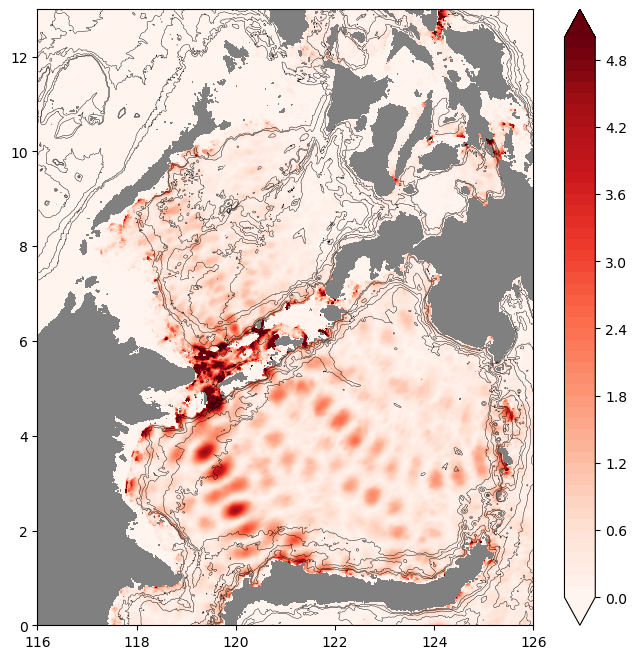

In [9]:
plt.figure(figsize=(8,8))
plt.contourf(lon, lat, np.mean(APE2_v3_vint,axis=0), cmap='Reds', vmin=0 , vmax=5, levels = np.arange(0, 5.05, 0.1), extend='both')

plt.colorbar()
plt.contourf(lon, lat, np.where(land_mask, 1, np.nan), colors=['gray'])
plt.contour(lon, lat, depth, levels=[500, 1000, 2000, 3000, 4000], colors='k', linewidths=0.3)
plt.xlim(116,126)
plt.ylim(0, 13)

Text(0.5, 1.0, 'Mean APE Vertical Integral (J/m^2)')

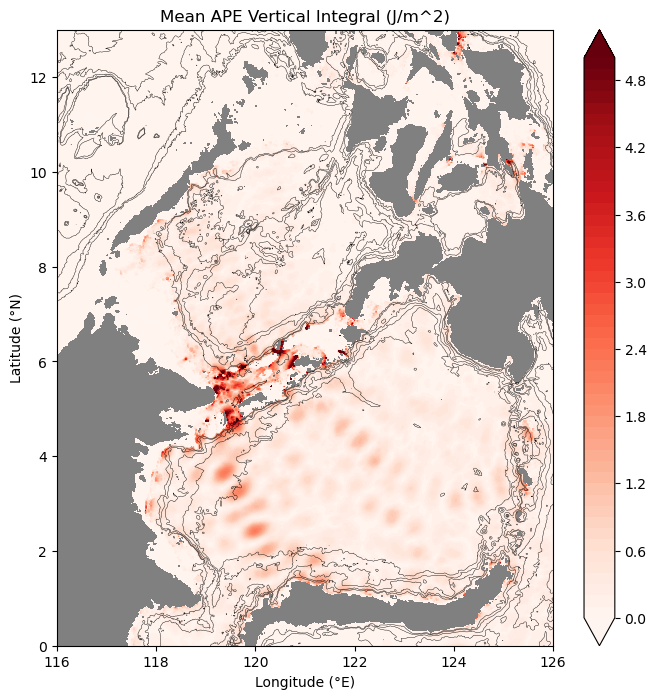

In [10]:
plt.figure(figsize=(8,8))
plt.contourf(lon,lat, np.mean(APE2_v4_1tidal,axis=0), cmap='Reds', vmin=0 , vmax=5, levels = np.arange(0, 5.05, 0.1), extend='both')
plt.colorbar()
plt.contourf(lon, lat, np.where(land_mask, 1, np.nan), colors=['gray'])
plt.contour(lon, lat, depth, levels=[500, 1000, 2000, 3000, 4000], colors='k', linewidths=0.3)
plt.xlim(116,126)
plt.ylim(0, 13)
plt.xlabel('Longitude (°E)')
plt.ylabel('Latitude (°N)')
plt.title('Mean APE Vertical Integral (J/m^2)')

Text(0.5, 1.0, 'Mean Vertical Integrated Kinetic Energy (J/m^2)')

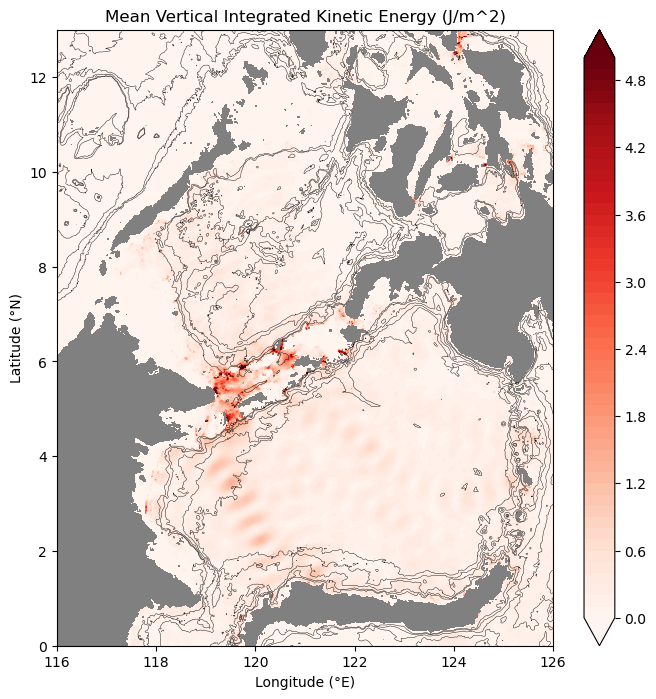

In [11]:
plt.figure(figsize=(8,8))
plt.contourf(lon,lat, np.mean(KE_vint,axis=0), cmap='Reds', vmin=0 , vmax=5, levels = np.arange(0, 5.05, 0.1), extend='both')
plt.colorbar()
plt.contourf(lon, lat, np.where(land_mask, 1, np.nan), colors=['gray'])
plt.contour(lon, lat, depth, levels=[500, 1000, 2000, 3000, 4000], colors='k', linewidths=0.3)
plt.xlim(116,126)
plt.ylim(0, 13)
plt.xlabel('Longitude (°E)')
plt.ylabel('Latitude (°N)')
plt.title('Mean Vertical Integrated Kinetic Energy (J/m^2)')

In [54]:
lat[630]

<xarray.DataArray 'YC' ()> Size: 4B
array(3.005, dtype='>f4')
Coordinates:
    YC       >f4 4B 3.005
Attributes:
    standard_name:  latitude
    long_name:      latitude
    units:          degrees_north
    coordinate:     YC XC
    axis:           Y

Text(0, 0.5, 'Energy (J/m^2)')

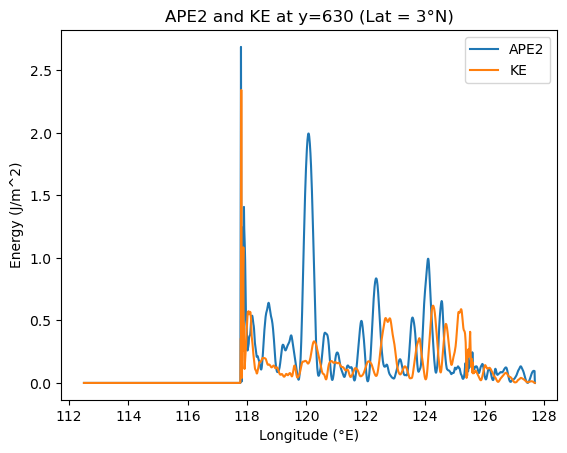

In [57]:
# plt.plot(APE2_v3_vint[0,1100])
plt.plot(lon, APE2_v4_1tidal[0,630], label='APE2')
plt.plot(lon, KE_vint[0,630], label='KE')
plt.legend()
plt.title('APE2 and KE at y=630 (Lat = 3°N)')
plt.xlabel('Longitude (°E)')
plt.ylabel('Energy (J/m^2)')

Text(0.5, 1.0, 'Mean Vertical Integrated Total Energy (J/m^2)')

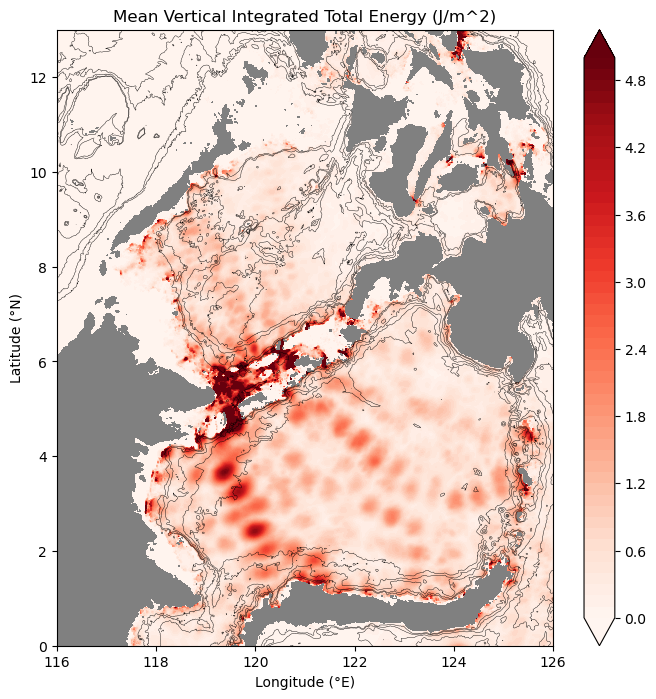

In [15]:
plt.figure(figsize=(8,8))
plt.contourf(lon,lat, np.mean(APE2_v3_vint+KE_vint, axis=0), cmap='Reds', vmin=0, vmax=5, levels = np.arange(0, 5.05, 0.1), extend='both')
plt.colorbar()
plt.contourf(lon, lat, np.where(land_mask, 1, np.nan), colors=['gray'])
plt.contour(lon, lat, depth, levels=[500, 1000, 2000, 3000, 4000], colors='k', linewidths=0.3)
plt.xlim(116,126)
plt.ylim(0, 13)
plt.xlabel('Longitude (°E)')
plt.ylabel('Latitude (°N)')
plt.title('Mean Vertical Integrated Total Energy (J/m^2)')

Text(0.5, 1.0, 'Mean Vertical Integrated Total Energy (J/m^2)')

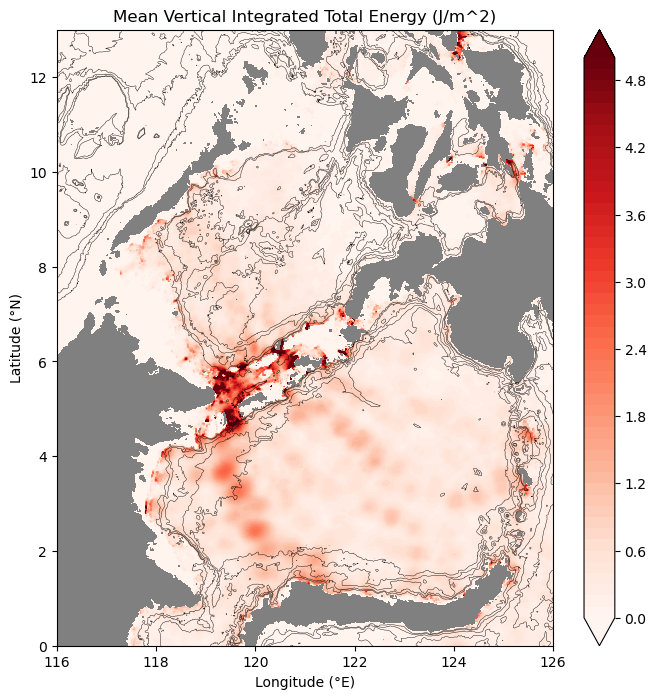

In [16]:
plt.figure(figsize=(8,8))
plt.contourf(lon,lat, np.mean(APE2_v4_1tidal+KE_vint, axis=0), cmap='Reds', vmin=0, vmax=5, levels = np.arange(0, 5.05, 0.1), extend='both')
plt.colorbar()
plt.contourf(lon, lat, np.where(land_mask, 1, np.nan), colors=['gray'])
plt.contour(lon, lat, depth, levels=[500, 1000, 2000, 3000, 4000], colors='k', linewidths=0.3)
plt.xlim(116,126)
plt.ylim(0, 13)
plt.xlabel('Longitude (°E)')
plt.ylabel('Latitude (°N)')
plt.title('Mean Vertical Integrated Total Energy (J/m^2)')

Text(0.5, 1.0, 'Energy Flux by model(W/m)')

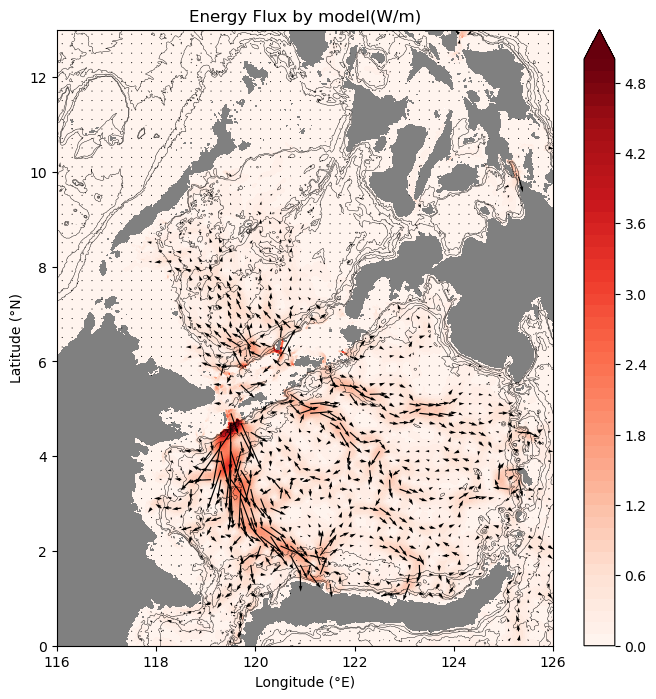

In [62]:
plt.figure(figsize=(8,8))
plt.contourf(lon,lat, Fxy_ver_int_mean, cmap='Reds', vmin=0, vmax=5, levels=np.arange(0, 5.05, 0.1), extend='max')
plt.colorbar()
plt.contourf(lon, lat, np.where(land_mask, 1, np.nan), colors=['gray'])
plt.contour(lon, lat, depth, levels=[500, 1000, 2000, 3000, 4000], colors='k', linewidths=0.3)
plt.quiver(lon[0:-1:20], lat[0:-1:20], Fx_ver_int_tavg_vint[0:-1:20, 0:-1:20], Fy_ver_int_tavg_vint[0:-1:20, 0:-1:20], scale=30, color='k')
plt.xlim(116,126)
plt.ylim(0, 13)
plt.xlabel('Longitude (°E)')
plt.ylabel('Latitude (°N)')
plt.title('Energy Flux by model(W/m)')

Text(0.5, 1.0, 'Available Energy Flux (W/m)')

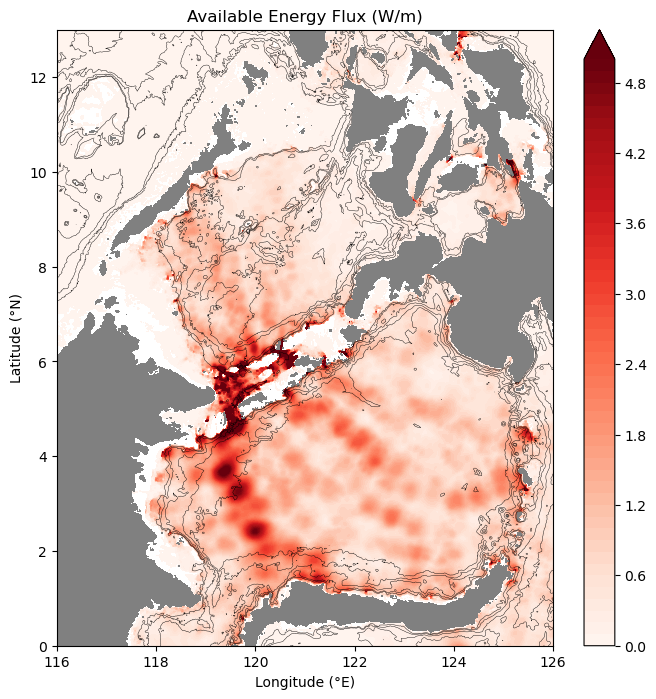

In [26]:
plt.figure(figsize=(8,8))
plt.contourf(lon,lat, Eflux_avail_v4, cmap='Reds', vmin=0, vmax=5, levels=np.arange(0, 5.05, 0.1), extend='max')
plt.colorbar()
plt.contourf(lon, lat, np.where(land_mask, 1, np.nan), colors=['gray'])
plt.contour(lon, lat, depth, levels=[500, 1000, 2000, 3000, 4000], colors='k', linewidths=0.3)
plt.xlim(116,126)
plt.ylim(0, 13)
plt.xlabel('Longitude (°E)')
plt.ylabel('Latitude (°N)')
plt.title('Available Energy Flux (W/m)')

In [64]:
# ratio
# Fxy_ver_int_mean = np.sqrt(Fx_ver_int_tavg_vint**2 + Fy_ver_int_tavg_vint**2)

ratio = Fxy_ver_int_mean.values/ Eflux_avail_v4.values

/tmp/ipykernel_968120/376729306.py:3: RuntimeWarning: divide by zero encountered in log10
  cf = plt.contourf(lon,lat, np.log10(ratio), cmap='Reds', levels = np.arange(-1, 0.2, 0.2))


Text(0.5, 1.0, 'ratio of baroclinic energy flux to available energy flux (log10 scale)')

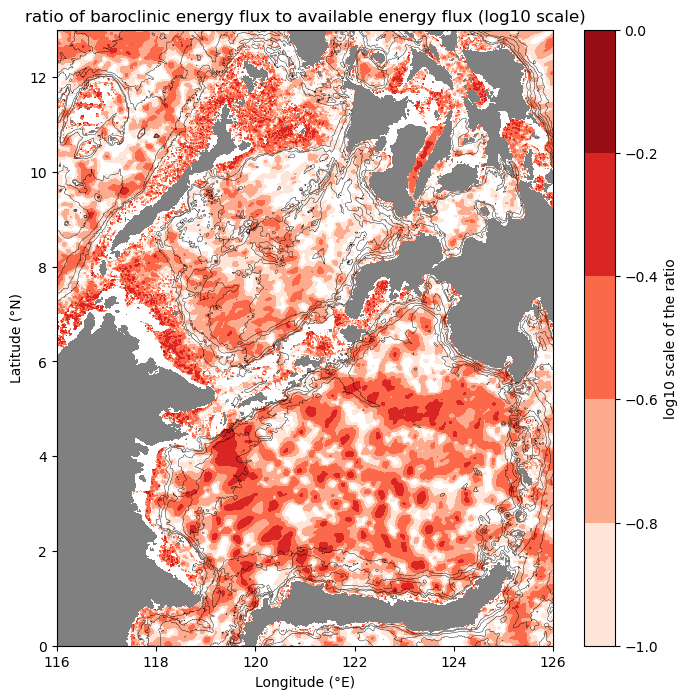

In [224]:
plt.figure(figsize=(8,8))
# plt.contourf(lon,lat, np.log10(ratio), cmap='Reds', levels = np.arange(-1, 0.2, 0.2))
cf = plt.contourf(lon,lat, np.log10(ratio), cmap='Reds', levels = np.arange(-1, 0.2, 0.2))
plt.colorbar(cf, label='log10 scale of the ratio')
plt.contourf(lon, lat, np.where(land_mask, 1, np.nan), colors=['gray'])
plt.contour(lon, lat, depth, levels=[500, 1000, 2000, 3000, 4000], colors='k', linewidths=0.3)
plt.xlim(116,126)
plt.ylim(0, 13)
plt.xlabel('Longitude (°E)')
plt.ylabel('Latitude (°N)')
plt.title('ratio of baroclinic energy flux to available energy flux (log10 scale)')

/tmp/ipykernel_1605017/2718297414.py:3: RuntimeWarning: divide by zero encountered in log10
  cf = plt.contourf(lon,lat, np.log10(ratio), cmap='RdBu_r', levels = np.arange(-1, 0.1, 0.1), extend='both')


Text(0.5, 1.0, 'ratio of baroclinic energy flux to available energy flux (log10 scale)')

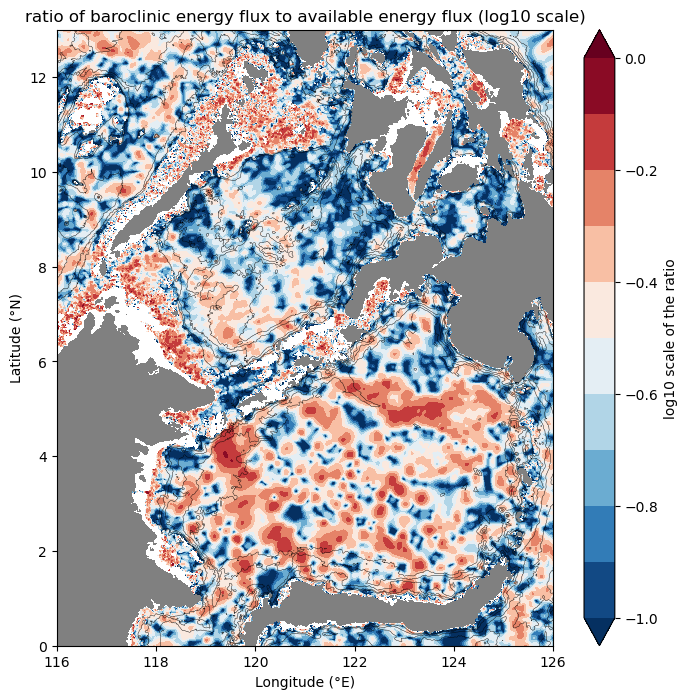

In [72]:
plt.figure(figsize=(8,8))
# plt.contourf(lon,lat, np.log10(ratio), cmap='Reds', levels = np.arange(-1, 0.2, 0.2))
cf = plt.contourf(lon,lat, np.log10(ratio), cmap='RdBu_r', levels = np.arange(-1, 0.1, 0.1), extend='both')
plt.colorbar(cf, label='log10 scale of the ratio')
plt.contourf(lon, lat, np.where(land_mask, 1, np.nan), colors=['gray'])
plt.contour(lon, lat, depth, levels=[500, 1000, 2000, 3000, 4000], colors='k', linewidths=0.3)
plt.xlim(116,126)
plt.ylim(0, 13)
plt.xlabel('Longitude (°E)')
plt.ylabel('Latitude (°N)')
plt.title('ratio of baroclinic energy flux to available energy flux (log10 scale)')

Text(0.5, 1.0, 'ratio of baroclinic energy flux to available energy flux (log10 scale)')

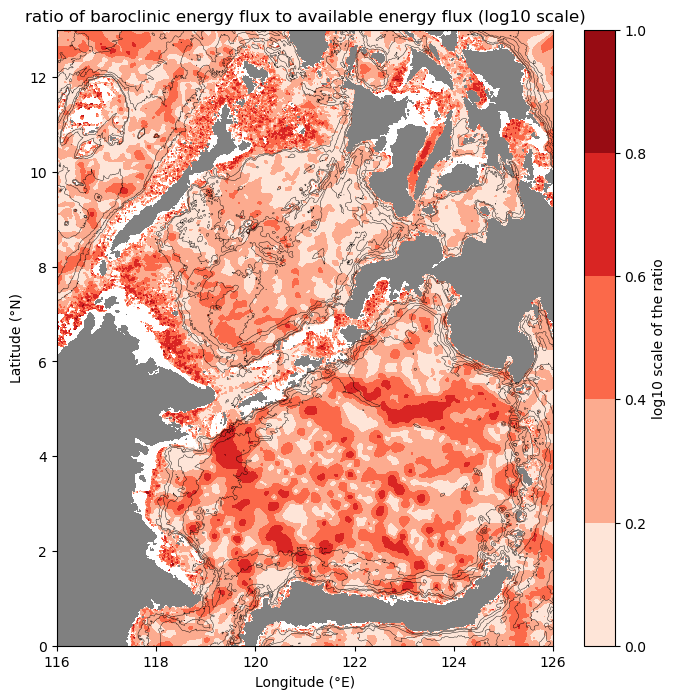

In [29]:
plt.figure(figsize=(8,8))
# plt.contourf(lon,lat, np.log10(ratio), cmap='Reds', levels = np.arange(-1, 0.2, 0.2))
cf = plt.contourf(lon,lat, ratio, cmap='Reds', levels = np.arange(0, 1.2, 0.2))
plt.colorbar(cf, label='log10 scale of the ratio')
plt.contourf(lon, lat, np.where(land_mask, 1, np.nan), colors=['gray'])
plt.contour(lon, lat, depth, levels=[500, 1000, 2000, 3000, 4000], colors='k', linewidths=0.3)
plt.xlim(116,126)
plt.ylim(0, 13)
plt.xlabel('Longitude (°E)')
plt.ylabel('Latitude (°N)')
plt.title('ratio of baroclinic energy flux to available energy flux (log10 scale)')

In [146]:
# check rho_ref and z_star

rho_ref = np.zeros((46, len(z_centers)))
for it in tqdm(range(46)):
    kt = it*13 + 6
    ds_rhoref0 = xr.open_dataset(f'rhoref_zstar_linear_case_ctrl_v4_1tidal/rhoref_t_{kt:03d}.nc')

    rho_ref[it, :] = ds_rhoref0.rho_ref.sel(x=900, y=1100).values

100%|██████████| 46/46 [00:14<00:00,  3.09it/s]


In [147]:
# check rho_ref and z_star

rho_ref_2 = np.zeros((15, len(z_centers)))
for it in tqdm(range(15)):
    kt = it*37 + 18
    print(kt)
    ds_rhoref0 = xr.open_dataset(f'rhoref_zstar_linear_case_ctrl_v3/rhoref_t_{kt:03d}.nc')

    rho_ref_2[it, :] = ds_rhoref0.rho_ref.sel(x=900, y=1100).values

  0%|          | 0/15 [00:00<?, ?it/s]

18


  7%|▋         | 1/15 [00:00<00:10,  1.38it/s]

55


 13%|█▎        | 2/15 [00:01<00:08,  1.62it/s]

...

 87%|████████▋ | 13/15 [00:05<00:00,  2.85it/s]

499


 93%|█████████▎| 14/15 [00:06<00:00,  1.65it/s]

536


100%|██████████| 15/15 [00:08<00:00,  1.82it/s]


In [25]:
zstar_1 = xr.open_dataset('rhoref_zstar_linear_case_ctrl_v4_1tidal/zstar_t_006.nc')
zstar_2 = xr.open_dataset('rhoref_zstar_linear_case_ctrl_v4_1tidal/zstar_t_110.nc')

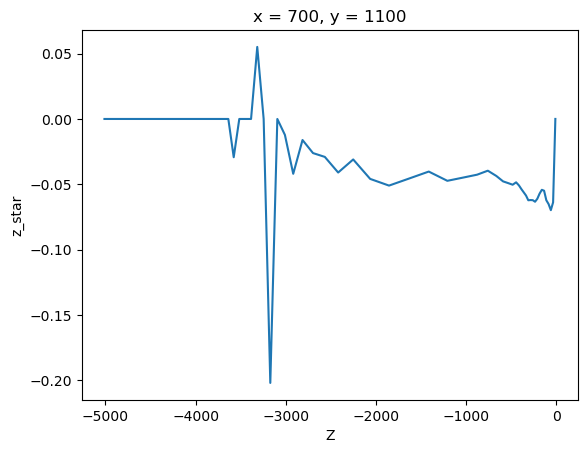

In [36]:
(zstar_1.z_star.sel(x=700, y=1100)-zstar_2.z_star.sel(x=700, y=1100)).plot()
# zstar_2.z_star.sel(x=700, y=1100).plot()

([<matplotlib.axis.XTick at 0x14aa34ce9ed0>,
 [Text(6, 0, '6'),
  Text(19, 0, '19'),
  Text(32, 0, '32'),
  Text(45, 0, '45'),
  Text(58, 0, '58'),
  Text(71, 0, '71'),
  Text(84, 0, '84'),
  Text(97, 0, '97'),
  Text(110, 0, '110'),
  Text(123, 0, '123'),
  Text(136, 0, '136'),
  Text(149, 0, '149'),
  Text(162, 0, '162'),
  Text(175, 0, '175'),
  Text(188, 0, '188'),
  Text(201, 0, '201'),
  Text(214, 0, '214'),
  Text(227, 0, '227'),
  Text(240, 0, '240'),
  Text(253, 0, '253'),
  Text(266, 0, '266'),
  Text(279, 0, '279'),
  Text(292, 0, '292'),
  Text(305, 0, '305'),
  Text(318, 0, '318'),
  Text(331, 0, '331'),
  Text(344, 0, '344'),
  Text(357, 0, '357'),
  Text(370, 0, '370'),
  Text(383, 0, '383'),
  Text(396, 0, '396'),
  Text(409, 0, '409'),
  Text(422, 0, '422'),
  Text(435, 0, '435'),
  Text(448, 0, '448'),
  Text(461, 0, '461'),
  Text(474, 0, '474'),
  Text(487, 0, '487'),
  Text(500, 0, '500'),
  Text(513, 0, '513'),
  Text(526, 0, '526'),
  Text(539, 0, '539'),
  Text(

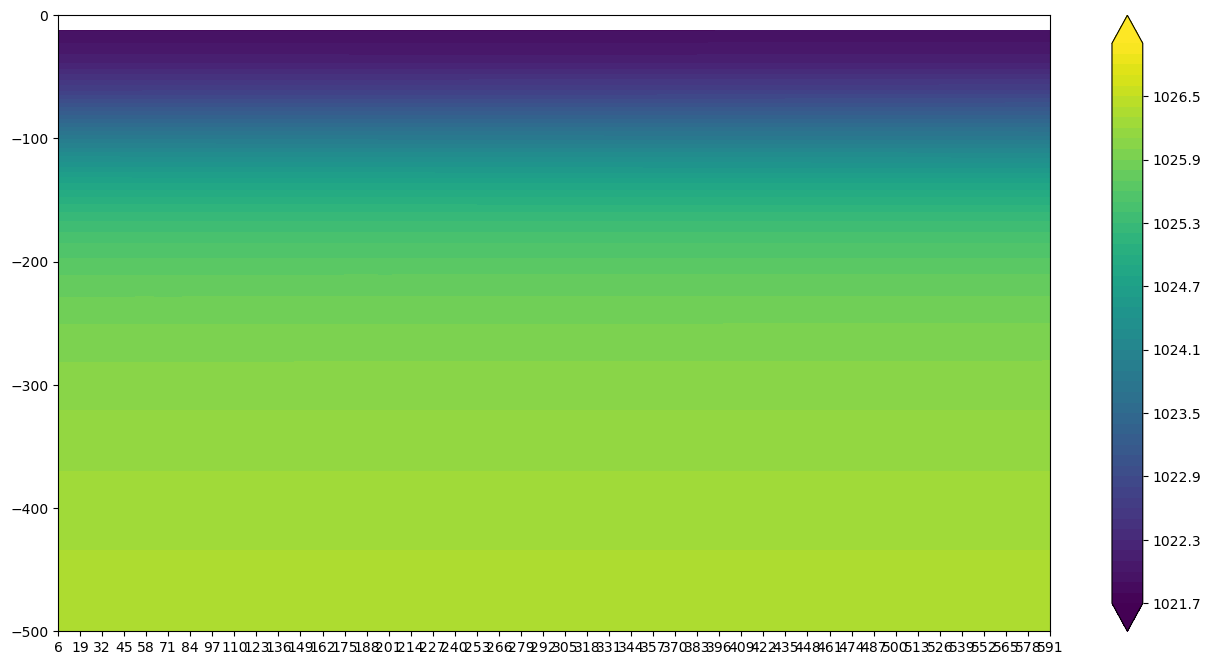

In [168]:
plt.figure(figsize=(16,8))
t_ref = np.arange(6, 6 + 13 * rho_ref.shape[0], 13)
plt.contourf(t_ref, z_centers, 1026.5+(rho_ref).T,levels = 1026.5+np.arange(-4.8, 0.6, 0.1), extend='both')
plt.ylim(-500, 0)
plt.colorbar()
plt.xticks(t_ref, labels=t_ref)
# plt.grid()

(-300.0, 0.0)

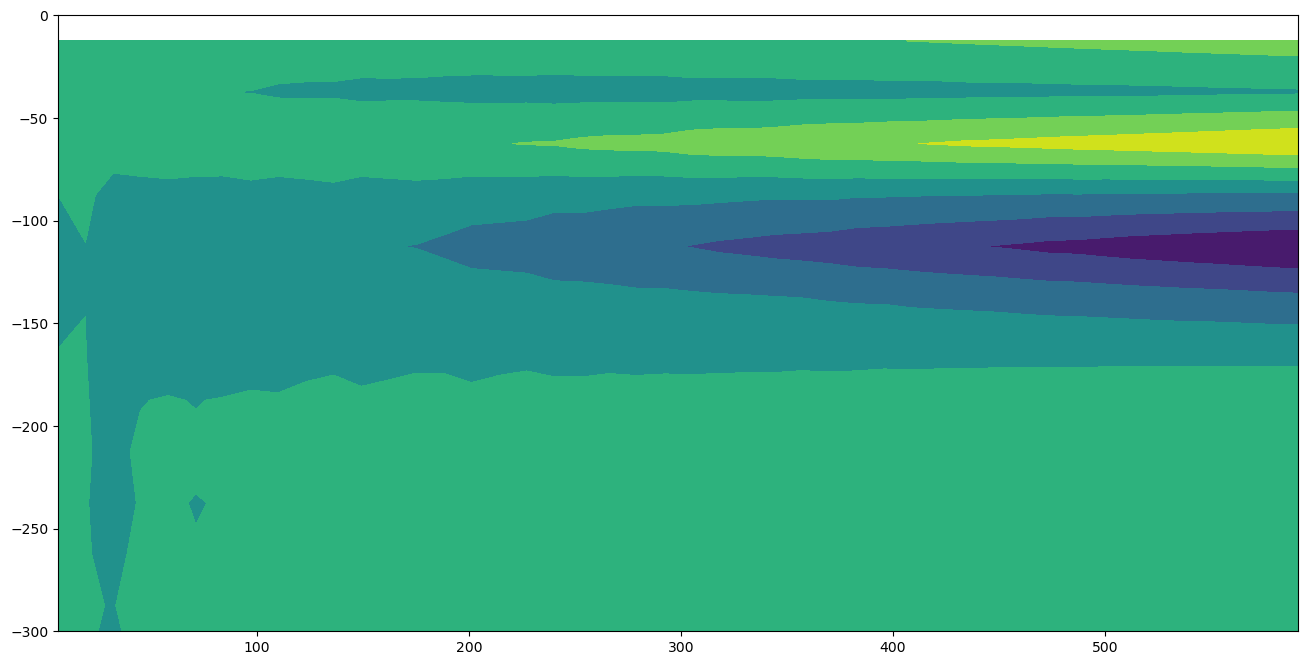

In [175]:
plt.figure(figsize=(16,8))
t_ref = np.arange(6, 6 + 13 * rho_ref.shape[0], 13)
plt.contourf(t_ref, z_centers, (rho_ref - rho_ref[0, :]).T)
plt.ylim(-1000, 0)
plt.ylim(-300, 0)

In [179]:
z_centers[10]

-262.5

Text(0.5, 1.0, 'Comparison of rho and rho_ref at Sulu Sea (z=262.5m)')

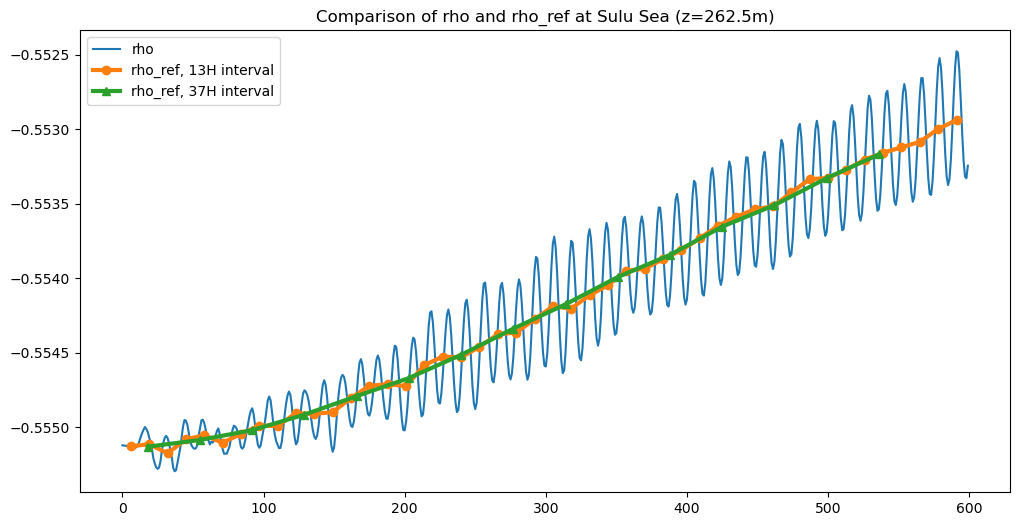

In [189]:
plt.figure(figsize=(12,6))
plt.plot(rho.isel(x=900, y=1100, z=10).rho.values, label='rho')
plt.plot(np.arange(6,599,13), rho_ref[:,10], 'o-',label='rho_ref, 13H interval', linewidth=3)
plt.plot(np.arange(18, 540, 37), rho_ref_2[:,10], '^-', label='rho_ref, 37H interval', linewidth=3)
plt.legend()
plt.title('Comparison of rho and rho_ref at Sulu Sea (z=262.5m)')

Text(0.5, 1.0, 'Comparison of rho and rho_ref at Sulu Sea (z=-137.5m)')

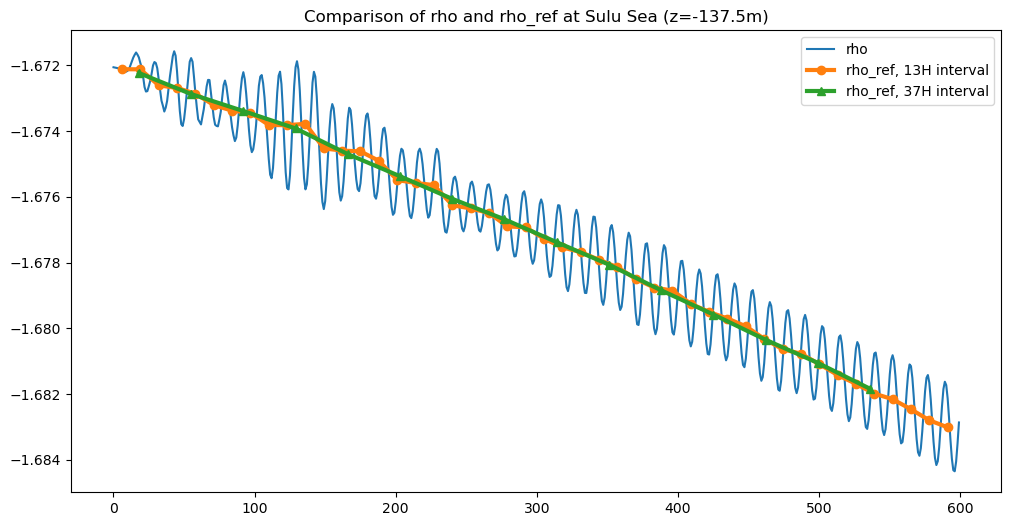

In [190]:
plt.figure(figsize=(12,6))
plt.plot(rho.isel(x=900, y=1100, z=5).rho.values, label='rho')
plt.plot(np.arange(6,599,13), rho_ref[:,5], 'o-', label='rho_ref, 13H interval', linewidth=3)
plt.plot(np.arange(18, 540, 37), rho_ref_2[:,5], '^-', label='rho_ref, 37H interval', linewidth=3)
plt.legend()
plt.title(f'Comparison of rho and rho_ref at Sulu Sea (z={z_centers[5]}m)')

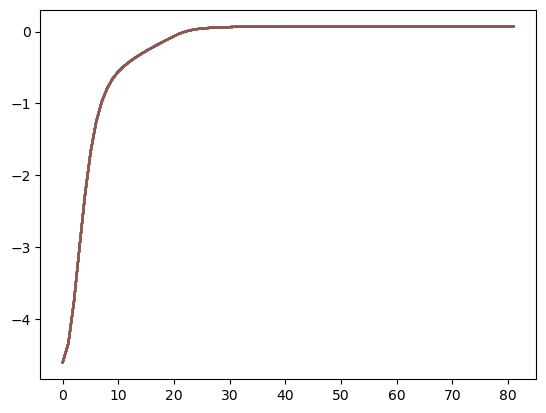

In [183]:
plt.plot(rho_ref[:,:].T)

In [40]:
rho = xr.open_zarr(os.path.join(data_dir, 'rho.zarr'), consolidated=False)

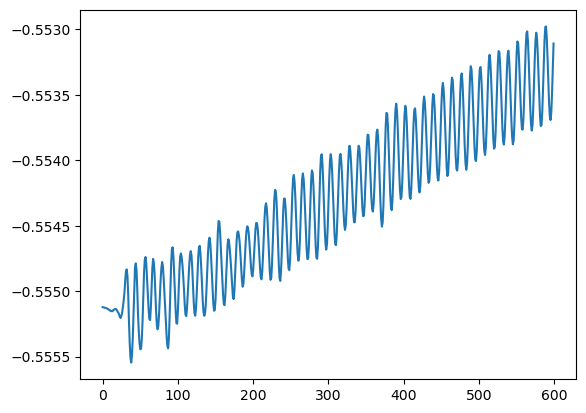

In [41]:
plt.plot(rho.isel(x=700, y=1100, z=10).rho.values, label='rho')

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [05:07<00:00,  3.08s/it]


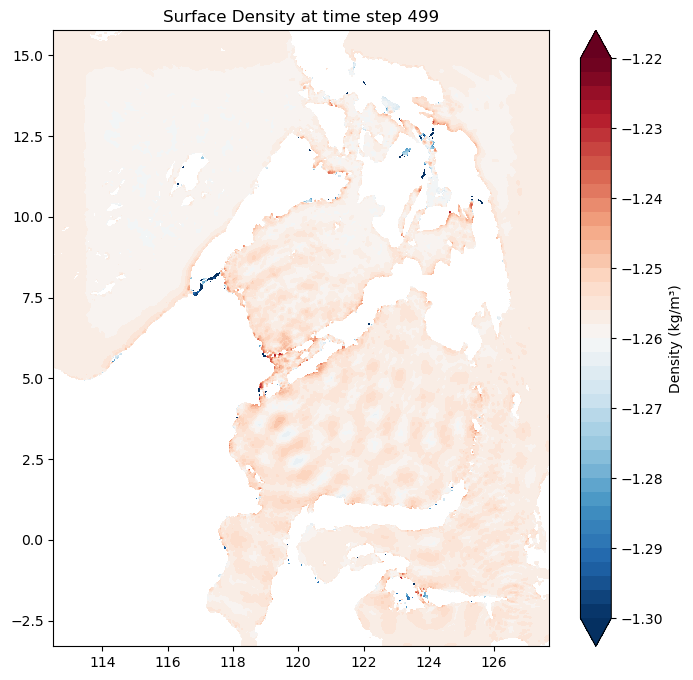

In [237]:
# plot surface velocity
ax = plt.figure(figsize=(8,8))
for t in tqdm(range(400, 500)):
    ax.clear()
    t0 = rho.isel(z=6, time=t).rho.values
    t0[t0>0] = np.nan
    plt.contourf(lon,lat, t0  , cmap='RdBu_r', levels = np.arange(-1.3, -1.22, 0.002), extend='both')
    plt.colorbar(label='Density (kg/m³)')
    plt.title(f'Surface Density at time step {t}')
    plt.savefig(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens_Tsorted_2/figures/rho_{t}.png')
    # plt.close()

In [251]:
# make animation 
import imageio
images = []
for t in tqdm(range(400, 500)):
    # t0 = theta.isel(z=6, time=t).theta.values
    # t0[t0==0] = np.nan
    # plt.contourf(lon,lat, t0  , cmap='RdBu_r', levels = np.arange(11, 11.32, 0.02), vmin = 11, vmax = 11.32)
    # plt.colorbar(label='Temperature (°C)')
    # plt.title(f'Surface Temperature at time step {t}')
    # plt.savefig(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/post_proc/linear_tests/case_lat45deg/figures/theta_{t}.png')
    images.append(imageio.imread(f'figures/rho_{t}.png'))
imageio.mimsave(f'figures/rho_animation.gif', images, duration=0.5)

images = []
for t in tqdm(range(400, 500)):
    images.append(imageio.imread(f'figures/u_velocity_{t}.png'))
imageio.mimsave(f'figures/u_velocity_animation.gif', images, duration=0.5)

  0%|          | 0/100 [00:00<?, ?it/s]/tmp/ipykernel_968120/1483138030.py:11: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(f'figures/rho_{t}.png'))
  0%|          | 0/100 [00:00<?, ?it/s]/tmp/ipykernel_968120/1483138030.py:16: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(f'figures/u_velocity_{t}.png'))
  0%|          | 0/100 [00:00<?, ?it/s]


FileNotFoundError: No such file: '/ceoas/cil/xiaohui/basin_modes/sulu_sea/post_proc/linear_tests/case_ctrl_bot_intens_Tsorted_2/figures/u_velocity_400.png'